# 3.1 CoSpar analysis (ALl9)

Author: Xuezhu Sunny Wang

## Dataset 📊

- Single-cell object of the plasma cells in ALl9

## Steps overview 📒
- Assign the clonotype to each plasma cell
- Label the pre-treatment (t0) and post-treatment (t1) samples
- Plot the fate probability and transition map of cell status (t0->t1)
  

In [1]:
import cospar as cs
import scanpy as sc
import pandas as pd
import scipy.sparse as ssp
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import os
import anndata as ad
from matplotlib.colors import to_hex
from typing import List
    
%matplotlib inline
%config InlineBackend.figure_format = 'svg' #'retina'    


In [2]:
cs.settings.verbosity = 2
cs.settings.data_path = "ALl9_pre_post_data"  # A relative path to save data. If not existed before, create a new one.
cs.settings.figure_path = "ALl9_pre_post_figure"  # A relative path to save figures. If not existed before, create a new one.
cs.settings.set_figure_params(
    format="png", dpi=75, fontsize=8
)  # use png to reduce file size.

## Load data

In [3]:
# Specify the path to your .h5ad file
file_path = "./ALl9_pre_post.h5ad"

# Load the AnnData object
adata_orig =ad.read(file_path)


In [4]:
adata_orig.obsm["X_emb"] = adata_orig.obsm["X_umap"]
adata_orig.obs["time_info"] = adata_orig.obs["orig.ident"]
adata_orig.uns["data_des"] = ["CARLIN"]

## Manually annotate the time info


In [5]:
# your mapping
time_map = {
    'ALl9postplasma': 't1',  'ALl9preplasma': 't0'
}

# assign based on mapping, all others default to "t0"
adata_orig.obs['time_info'] = (
    adata_orig.obs['time_info']
    .astype(str)       # make sure it's a string, not categorical codes
    .map(time_map)     # map with your dictionary
    .fillna('t0')      # default if not listed
)

# reinitialize with cellrank or your pipeline
cs.pp.initialize_adata_object(adata_orig)


Time points with clonal info: []


AnnData object with n_obs × n_vars = 7276 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.ig', 'percent.hb', 'unintegrated_clusters', 'seurat_clusters', 'barcode', 'mutation', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'barcode.1', 'clonotype', 'orig.ident.1', 'labelpart1', 'trashed', 'labelpart2', 'labelrep', 'time_info'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'var.features', 'var.features.rank'
    uns: 'data_des', 'time_ordering', 'clonal_time_points'
    obsm: 'X_pca', 'X_umap', 'X_emb', 'X_clone'

## Transcriptomic analysis

In [6]:
# 1) Global figure style (crisper fonts, white bg)
sc.settings.set_figure_params(dpi=150, facecolor='white')


/lab-share/Cardio-Pu-e2/Public/ch257181_sunny/miniconda3/envs/carlin/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


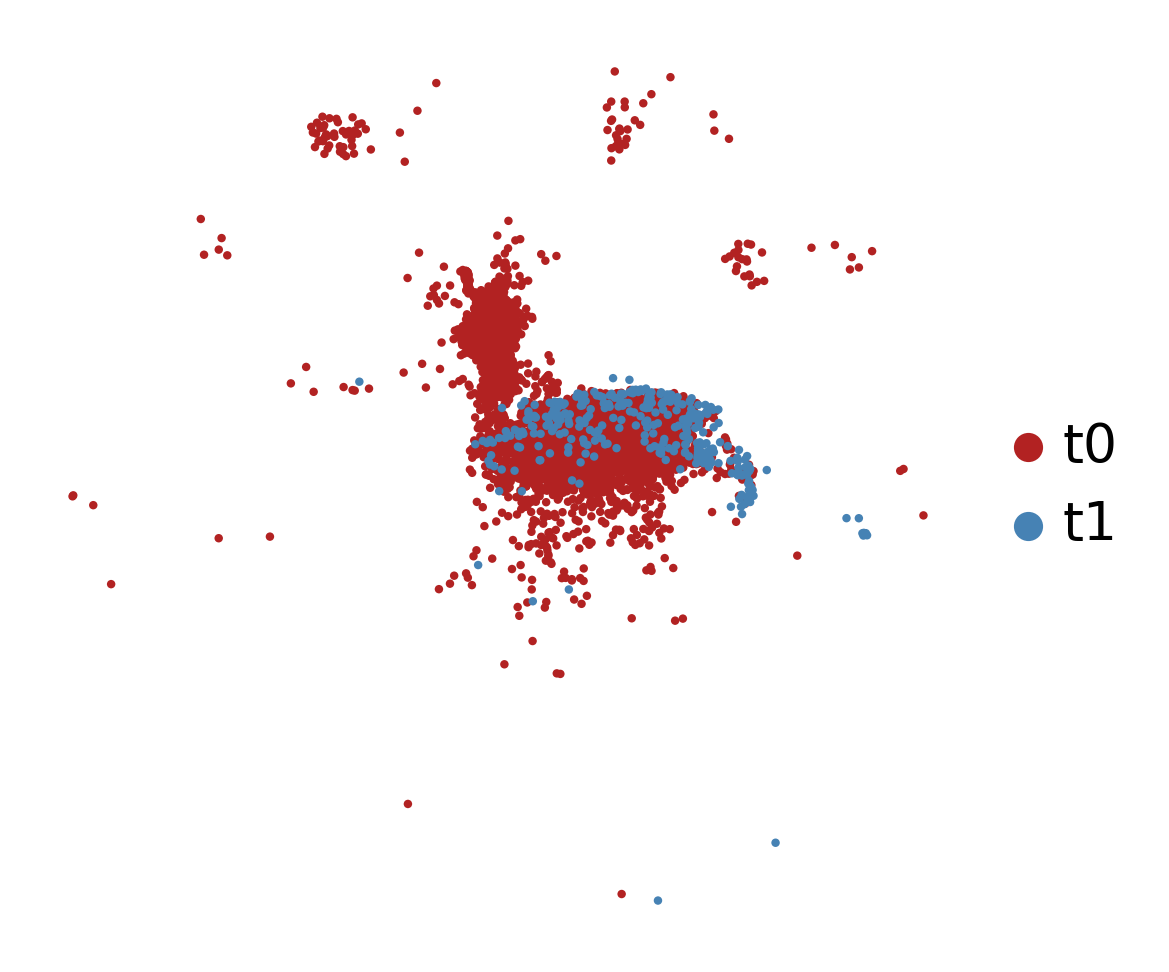

In [8]:
import matplotlib.pyplot as plt

# Define red vs blue colormap
colors = ['firebrick', 'steelblue']

sc.pl.embedding(
    adata_orig,
    basis='X_umap',
    color='time_info',
    palette=colors,   # enforce red/blue
    frameon=False,
    title='',
    save='_time_info'
)


/lab-share/Cardio-Pu-e2/Public/ch257181_sunny/miniconda3/envs/carlin/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


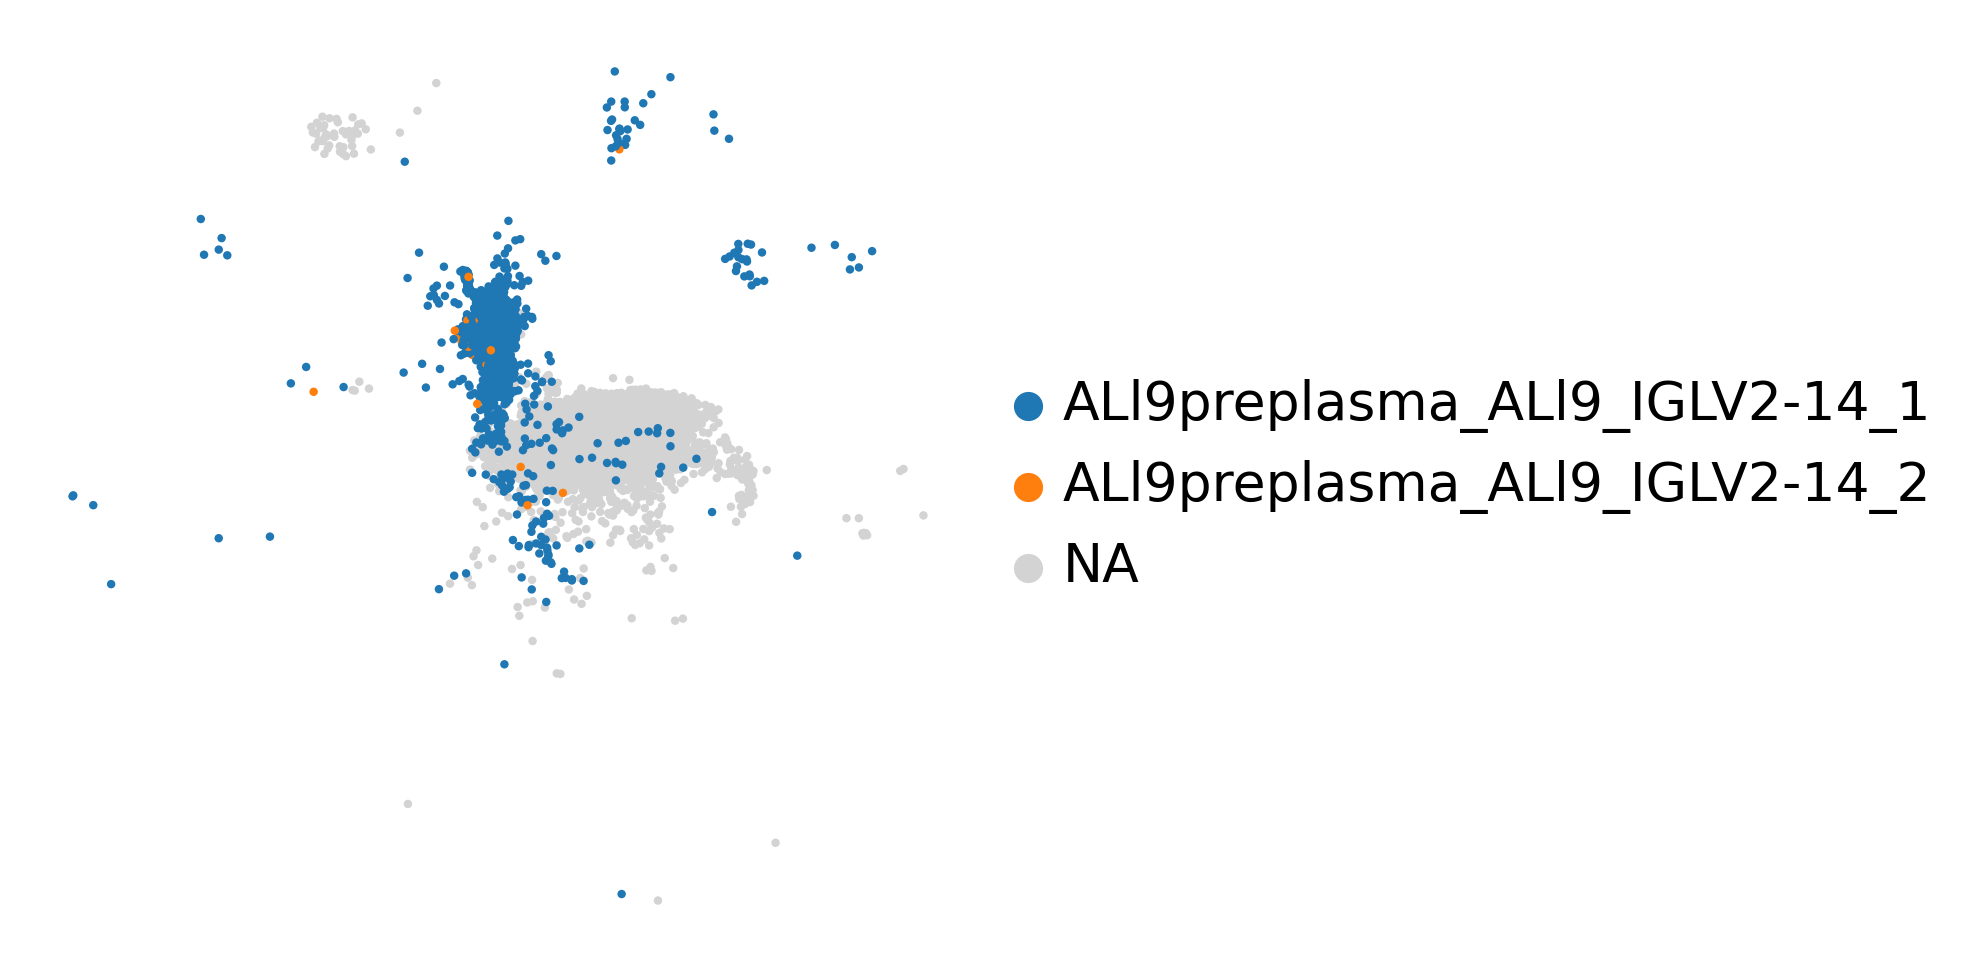

In [9]:
sc.pl.embedding(adata_orig,color='clonotype',basis='X_umap',frameon=False,title='',
               save='_clonotype')

In [10]:
adata_orig=adata_orig

# --- 1) Read CNMF usage table and set barcodes as index
sig_path = "plasma_cnmf_3_usage_norm_withoutIG_k=13.csv"
signature = pd.read_csv(sig_path)

# Mirror your R: rownames(signature) <- signature$X; signature$X <- NULL
if "X" in signature.columns:
    signature = signature.set_index("X")
else:
    # fall back to first column if needed
    signature = signature.set_index(signature.columns[0])

signature.index = signature.index.astype(str).str.strip()
signature = signature.apply(pd.to_numeric, errors="coerce")

# --- 2) Add the 8 zero rows for specified barcodes (only if missing)
extra_barcodes = [
    "ALl9preplasma_GTCACGGAGTGCGTGA-1",
    "ALl5preplasma_GCATGTATCACAGTAC-1",
    "N1plasma_ACGAGGACATCAGTAC-1",
    "N1plasma_GCTCTGTAGAAACGAG-1",
    "ALl6preplasma_TAGACCACAGTATGCT-1",
    "ALl3preplasma_TAAACCGGTACTCTCC-1",
    "N2plasma_CAGGTGCGTCTTGATG-1",
    "ALk6plasma_ATTACTCAGCCAGTTT-1",
]
missing = [b for b in extra_barcodes if b not in signature.index]
if missing:
    new_rows = pd.DataFrame(0.0, index=missing, columns=signature.columns)
    signature = pd.concat([signature, new_rows], axis=0)

# --- 3) Align to adata_orig’s cells and join into .obs
adata_orig.obs_names = adata_orig.obs_names.astype(str).str.strip()
usage_aligned = signature.reindex(adata_orig.obs_names)  # overlap only
adata_orig.obs = adata_orig.obs.join(usage_aligned)

print(
    f"CNMF usages aligned to {usage_aligned.notna().any(axis=1).sum()}/{adata_orig.n_obs} cells."
)

# --- 4) Compute averages per clonotype (features as rows, clonotype as columns)
usage_cols = [c for c in signature.columns if c.startswith("Usage_")]
if "clonotype" not in adata_orig.obs.columns:
    raise KeyError("adata_orig.obs['clonotype'] not found.")

avg_mat = (
    adata_orig.obs.groupby("clonotype")[usage_cols]
    .mean(numeric_only=True)
    .T
)
print("avg_mat shape:", avg_mat.shape)
# avg_mat.to_csv("avg_mat_by_clonotype_usage_only.csv")


CNMF usages aligned to 7276/7276 cells.
avg_mat shape: (13, 2)


In [11]:
import numpy as np
import pandas as pd

# ====== CONFIG ======
# Threshold above which a component is considered "positive"
THR = 0.20   # change to 0.0, 0.1, 0.3, etc. as you prefer

# Component columns we care about
need_any = ["Usage_11", "Usage_2"]  # we only need at least one of these
present = [c for c in need_any if c in adata_orig.obs.columns]
if len(present) == 0:
    raise ValueError("Neither 'Usage_11' nor 'Usage_2' is present in adata_orig.obs")

# Ensure numeric
for c in present:
    adata_orig.obs[c] = pd.to_numeric(adata_orig.obs[c], errors="coerce")

# Initialize group as "Other"
group = pd.Series(index=adata_orig.obs.index, data="Other", dtype="object")

# Priority 1: Usage_11+
if "Usage_11" in present:
    mask_11 = adata_orig.obs["Usage_11"].astype(float) >= THR
    group.loc[mask_11] = "Usage_11+"
else:
    mask_11 = pd.Series(False, index=adata_orig.obs.index)

# Priority 2: Usage_2+ (only among those NOT already labeled as Usage_11+)
if "Usage_2" in present:
    mask_2 = (adata_orig.obs["Usage_2"].astype(float) >= THR) & (~mask_11)
    group.loc[mask_2] = "Usage_2+"

# Save to .obs
adata_orig.obs["cnmf_group"] = pd.Categorical(
    group,
    categories=["Usage_11+", "Usage_2+", "Other"],  # fixed order for plotting
    ordered=True
)

# Optional: quick counts
vc = adata_orig.obs["cnmf_group"].value_counts(dropna=False)
print(f"Labeled {len(group)} cells into cnmf_group with THR={THR}.")
print("Value counts:\n", vc)


Labeled 7276 cells into cnmf_group with THR=0.2.
Value counts:
 cnmf_group
Usage_2+     4048
Other        3166
Usage_11+      62
Name: count, dtype: int64


In [13]:
adata_orig.obs["state_info"] = adata_orig.obs["cnmf_group"]
adata_orig.uns["state_info"] = adata_orig.obs["cnmf_group"]

/lab-share/Cardio-Pu-e2/Public/ch257181_sunny/miniconda3/envs/carlin/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


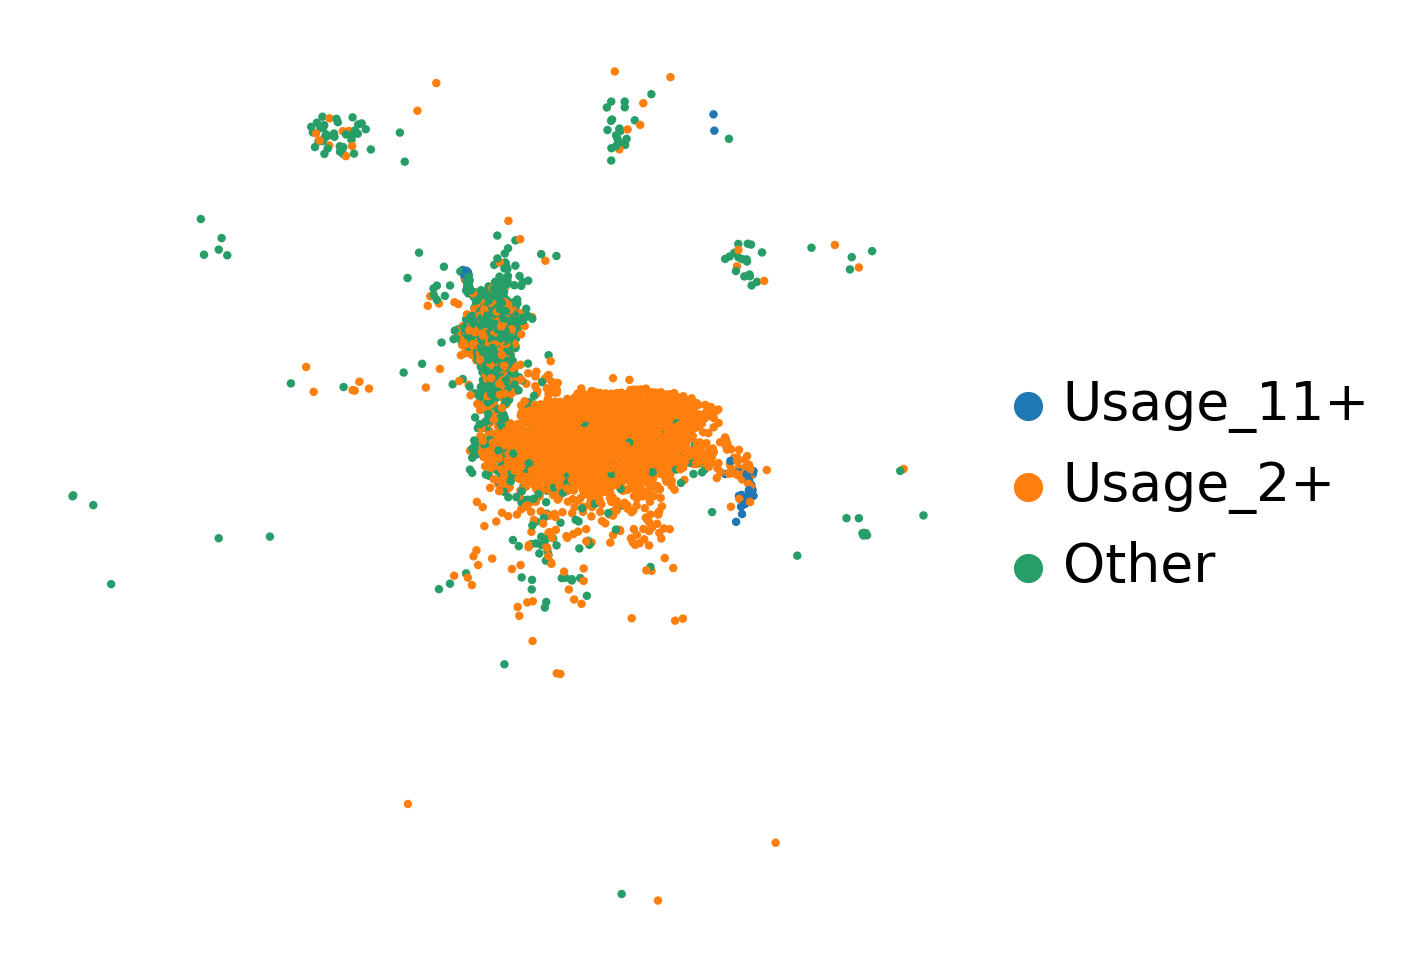

In [14]:
sc.pl.embedding(adata_orig,color='cnmf_group',basis='X_umap',frameon=False,title='',
               save='_clonotype')

## Basic clone statistics

In [15]:
import pandas as pd
import anndata as ad

# --- 1) Subset AnnData object (assuming adata_orig is an AnnData) ---
adata_orig_subset = adata_orig[adata_orig.obs["orig.ident"] == "ALl9preplasma"].copy()

# --- 2) Read BCR files ---
adata_origfiltered = pd.read_csv("../ANNO_XS01KF2024040123_PM-XS01KF2024040123-41/Cleandata/LCW-5-b/LCW-5-b/outs/filtered_contig_annotations.csv")
adata_origconsensus = pd.read_csv("../ANNO_XS01KF2024040123_PM-XS01KF2024040123-41/Cleandata/LCW-5-b/LCW-5-b/outs/consensus_annotations.csv")

# --- 3) Prefix barcodes with "ALl9preplasma_" ---
adata_origfiltered["barcode"] = "ALl9preplasma_" + adata_origfiltered["barcode"].astype(str)

# --- 4) Filter IGL chains (from filtered_contig_annotations) ---
adata_origfilteredK = (
    adata_origfiltered[adata_origfiltered["chain"] == "IGL"]
    .loc[:, ["barcode", "raw_clonotype_id"]]
    .drop_duplicates()
)

# Remove empty clonotypes
adata_origfilteredK = adata_origfilteredK[adata_origfilteredK["raw_clonotype_id"].astype(str).str.len() > 0]

# --- 5) Make lookup dictionary (barcode -> clonotype) ---
barcode2clonotype = dict(zip(adata_origfilteredK["barcode"], adata_origfilteredK["raw_clonotype_id"]))

# --- 6) Build DataFrame of Cell_ID and Clone_ID (initially clonotype ids) ---
cell_ids = adata_orig_subset.obs_names.to_list()
clone_ids = [barcode2clonotype.get(cell, None) for cell in cell_ids]

df_X_clone1 = pd.DataFrame({
    "Cell_ID": cell_ids,
    "Clone_ID": clone_ids
})

print("Before replacement (Clone_ID = raw clonotype_id):")
print(df_X_clone1.head())

# ========================= NEW PART: build region-signature per clonotype =========================
# Work only with IGL rows from consensus file and pick desired columns
cols = ['fwr1_nt', 'cdr1_nt', 'fwr2_nt', 'cdr2_nt', 'fwr3_nt', 'cdr3_nt', 'fwr4_nt']
consensus_IGL = adata_origconsensus[adata_origconsensus["chain"] == "IGL"].copy()

# Keep only needed columns (skip missing columns gracefully)
available_cols = ['clonotype_id'] + [c for c in cols if c in consensus_IGL.columns]
consensus_IGL = consensus_IGL.loc[:, available_cols].copy()

# Helper: for groupby aggregation, take the first non-empty string
def first_non_empty(series):
    for v in series:
        if isinstance(v, str) and v != "":
            return v
        if pd.notna(v) and str(v) != "" and str(v) != "nan":
            return str(v)
    return ""

# Aggregate to one row per clonotype_id, preferring the first non-empty per region
agg_dict = {c: first_non_empty for c in available_cols if c != 'clonotype_id'}
sig_df = (consensus_IGL
          .groupby('clonotype_id', as_index=False)
          .agg(agg_dict))

# Ensure all requested columns exist (fill missing ones with empty string)
for c in cols:
    if c not in sig_df.columns:
        sig_df[c] = ""

# Build the signature string in the requested order, use '|' as delimiter
sig_df['signature'] = sig_df[cols].astype(str).apply(lambda r: "".join([x if x is not None else "" for x in r]), axis=1)

# Mapping: clonotype_id -> concatenated signature
clonotype2signature = dict(zip(sig_df['clonotype_id'], sig_df['signature']))

# --- Replace Clone_ID (raw clonotype id) with the region signature when available ---
df_X_clone1['Clone_ID'] = df_X_clone1['Clone_ID'].map(clonotype2signature).fillna(df_X_clone1['Clone_ID'])

print("\nAfter replacement (Clone_ID = concatenated nt regions):")
print(df_X_clone1.head())


Before replacement (Clone_ID = raw clonotype_id):
                            Cell_ID       Clone_ID
0  ALl9preplasma_AAACCTGAGAGCCCAA-1     clonotype1
1  ALl9preplasma_AAACCTGAGATGGCGT-1   clonotype238
2  ALl9preplasma_AAACCTGAGCCCGAAA-1     clonotype1
3  ALl9preplasma_AAACCTGAGGCAGGTT-1  clonotype2057
4  ALl9preplasma_AAACCTGAGTAGTGCG-1           None

After replacement (Clone_ID = concatenated nt regions):
                            Cell_ID  \
0  ALl9preplasma_AAACCTGAGAGCCCAA-1   
1  ALl9preplasma_AAACCTGAGATGGCGT-1   
2  ALl9preplasma_AAACCTGAGCCCGAAA-1   
3  ALl9preplasma_AAACCTGAGGCAGGTT-1   
4  ALl9preplasma_AAACCTGAGTAGTGCG-1   

                                            Clone_ID  
0  CAGTCTGCCCTGACTCAGCCTGCCTCCGTGTCTGGGTCTCCTGGAC...  
1  CAGCTTATACTGACTCAATCGCCCTCTGCCTCTGCCTCACTGGGAG...  
2  CAGTCTGCCCTGACTCAGCCTGCCTCCGTGTCTGGGTCTCCTGGAC...  
3  CAGACTGTGGTGACTCAGGAGCCCTCACTGACTGTGTCCCCAGGAG...  
4                                               None  


In [16]:
import pandas as pd
import anndata as ad

# --- 1) Subset AnnData object (assuming adata_orig is an AnnData) ---
adata_orig_subset = adata_orig[adata_orig.obs["orig.ident"] == "ALl9postplasma"].copy()

# --- 2) Read BCR files ---
adata_origfiltered = pd.read_csv("../BCR/sc0413/lcwc3-5/outs/filtered_contig_annotations.csv")
adata_origconsensus = pd.read_csv("../BCR/sc0413/lcwc3-5/outs/consensus_annotations.csv")

# --- 3) Prefix barcodes with "ALl9preplasma_" ---
adata_origfiltered["barcode"] = "ALl9postplasma_" + adata_origfiltered["barcode"].astype(str)



# --- 4) Filter IGL chains (from filtered_contig_annotations) ---
adata_origfilteredK = (
    adata_origfiltered[adata_origfiltered["chain"] == "IGL"]
    .loc[:, ["barcode", "raw_clonotype_id"]]
    .drop_duplicates()
)

# Remove empty clonotypes
adata_origfilteredK = adata_origfilteredK[adata_origfilteredK["raw_clonotype_id"].astype(str).str.len() > 0]

# --- 5) Make lookup dictionary (barcode -> clonotype) ---
barcode2clonotype = dict(zip(adata_origfilteredK["barcode"], adata_origfilteredK["raw_clonotype_id"]))

# --- 6) Build DataFrame of Cell_ID and Clone_ID (initially clonotype ids) ---
cell_ids = adata_orig_subset.obs_names.to_list()
clone_ids = [barcode2clonotype.get(cell, None) for cell in cell_ids]

df_X_clone2 = pd.DataFrame({
    "Cell_ID": cell_ids,
    "Clone_ID": clone_ids
})

print("Before replacement (Clone_ID = raw clonotype_id):")
print(df_X_clone2.head())

# ========================= NEW PART: build region-signature per clonotype =========================
# Work only with IGL rows from consensus file and pick desired columns
cols = ['fwr1_nt', 'cdr1_nt', 'fwr2_nt', 'cdr2_nt', 'fwr3_nt', 'cdr3_nt', 'fwr4_nt']
consensus_IGL = adata_origconsensus[adata_origconsensus["chain"] == "IGL"].copy()

# Keep only needed columns (skip missing columns gracefully)
available_cols = ['clonotype_id'] + [c for c in cols if c in consensus_IGL.columns]
consensus_IGL = consensus_IGL.loc[:, available_cols].copy()

# Helper: for groupby aggregation, take the first non-empty string
def first_non_empty(series):
    for v in series:
        if isinstance(v, str) and v != "":
            return v
        if pd.notna(v) and str(v) != "" and str(v) != "nan":
            return str(v)
    return ""

# Aggregate to one row per clonotype_id, preferring the first non-empty per region
agg_dict = {c: first_non_empty for c in available_cols if c != 'clonotype_id'}
sig_df = (consensus_IGL
          .groupby('clonotype_id', as_index=False)
          .agg(agg_dict))

# Ensure all requested columns exist (fill missing ones with empty string)
for c in cols:
    if c not in sig_df.columns:
        sig_df[c] = ""

# Build the signature string in the requested order, use '|' as delimiter
sig_df['signature'] = sig_df[cols].astype(str).apply(lambda r: "".join([x if x is not None else "" for x in r]), axis=1)

# Mapping: clonotype_id -> concatenated signature
clonotype2signature = dict(zip(sig_df['clonotype_id'], sig_df['signature']))

# --- Replace Clone_ID (raw clonotype id) with the region signature when available ---
df_X_clone2['Clone_ID'] = df_X_clone2['Clone_ID'].map(clonotype2signature).fillna(df_X_clone2['Clone_ID'])

print("\nAfter replacement (Clone_ID = concatenated nt regions):")
print(df_X_clone2.head())


Before replacement (Clone_ID = raw clonotype_id):
                             Cell_ID      Clone_ID
0  ALl9postplasma_AAACGGGCAAGCCGTC-1  clonotype436
1  ALl9postplasma_AAAGCAAAGGAACTGC-1          None
2  ALl9postplasma_AAAGCAAGTCCGTTAA-1          None
3  ALl9postplasma_AAAGTAGCATCGTCGG-1          None
4  ALl9postplasma_AAATGCCTCAAGATCC-1          None

After replacement (Clone_ID = concatenated nt regions):
                             Cell_ID  \
0  ALl9postplasma_AAACGGGCAAGCCGTC-1   
1  ALl9postplasma_AAAGCAAAGGAACTGC-1   
2  ALl9postplasma_AAAGCAAGTCCGTTAA-1   
3  ALl9postplasma_AAAGTAGCATCGTCGG-1   
4  ALl9postplasma_AAATGCCTCAAGATCC-1   

                                            Clone_ID  
0  CAGTCTGCCCTGACTCAGCCTGCCTCCGTGTCTGGGTCTCCTGGAC...  
1                                               None  
2                                               None  
3                                               None  
4                                               None  


In [17]:
df_X_clone = pd.concat([df_X_clone1 ,df_X_clone2])

In [18]:
df_X_clone = df_X_clone.groupby("Clone_ID").filter(lambda x: len(x) >= 2)

In [19]:
cs.pp.get_X_clone(adata_orig, df_X_clone["Cell_ID"], df_X_clone["Clone_ID"])

100%|██████████| 4597/4597 [00:00<00:00, 2101953.07it/s]

reorder clones


In [20]:
cs.hf.check_available_choices(adata_orig)

Available transition maps: []
Available clusters: ['Usage_11+', 'Usage_2+', 'Other']
Available time points: ['t0' 't1']
Clonal time points: ['t0' 't1']


/lab-share/Cardio-Pu-e2/Public/ch257181_sunny/miniconda3/envs/carlin/lib/python3.8/site-packages/cospar/plotting/_clone.py:283: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(fig_width, fig_height))


<AxesSubplot: title={'center': 'ID: 29'}>

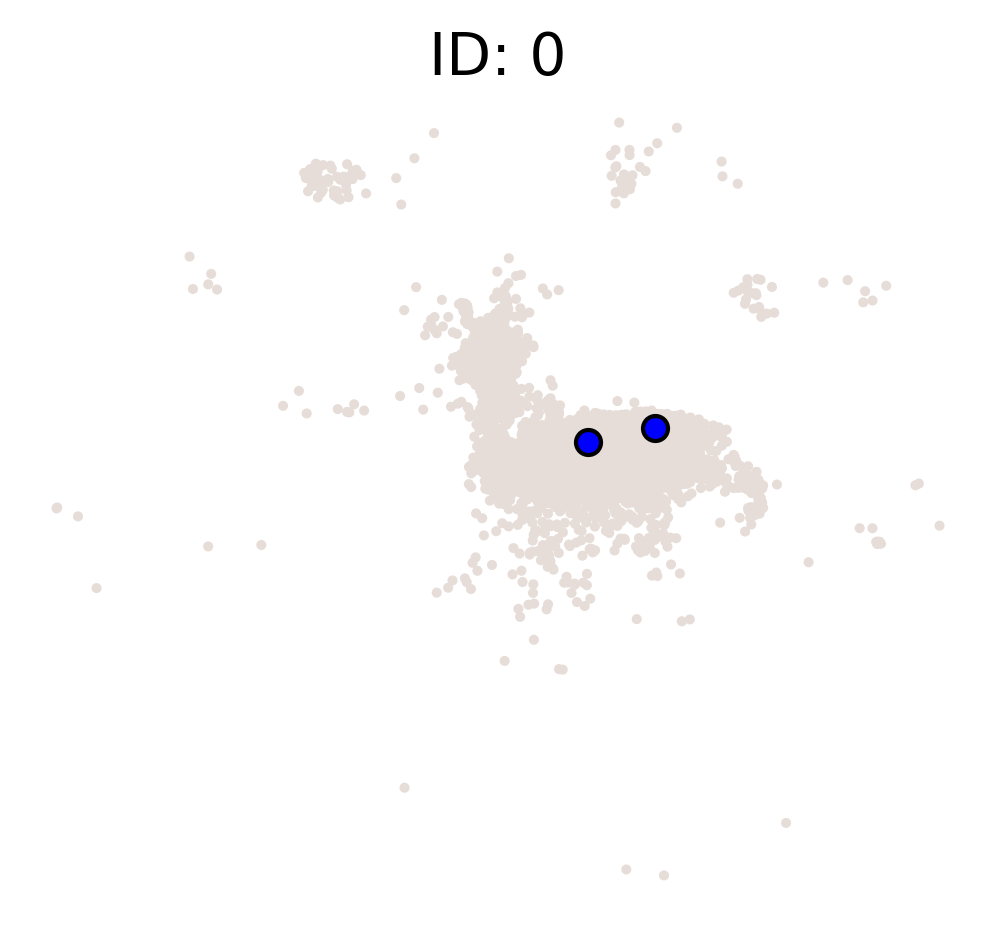

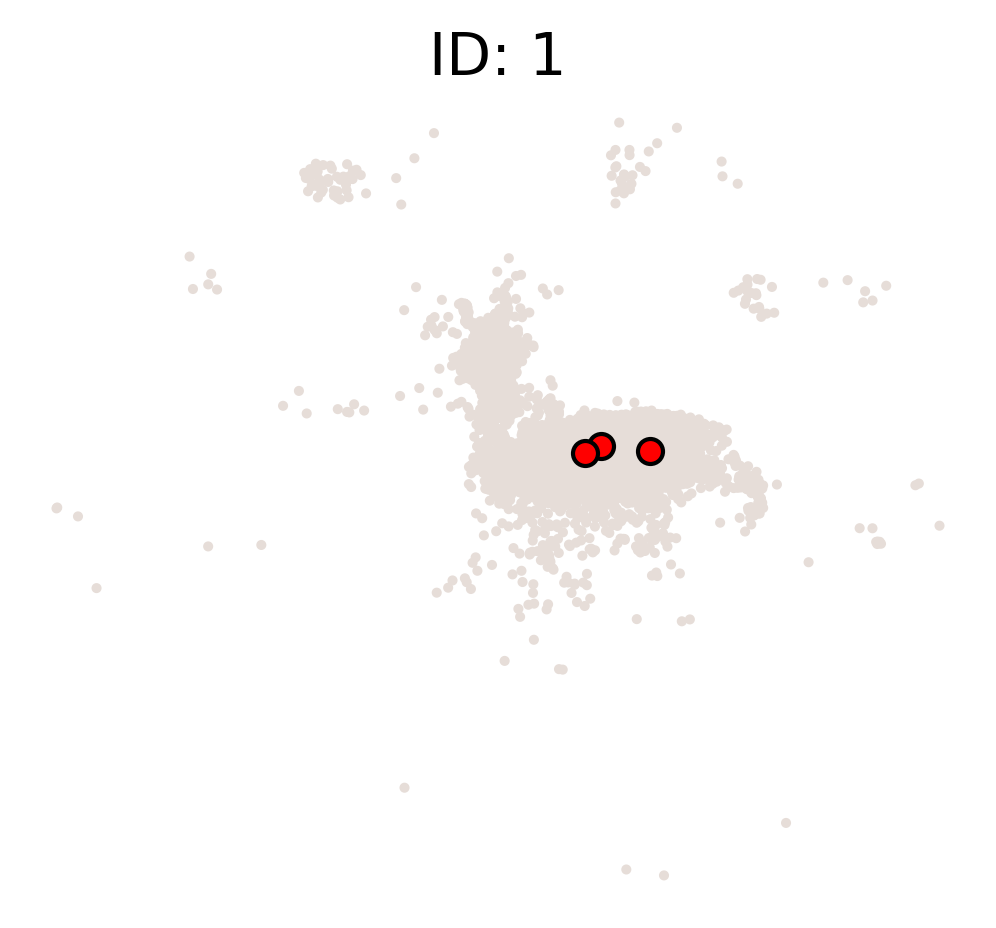

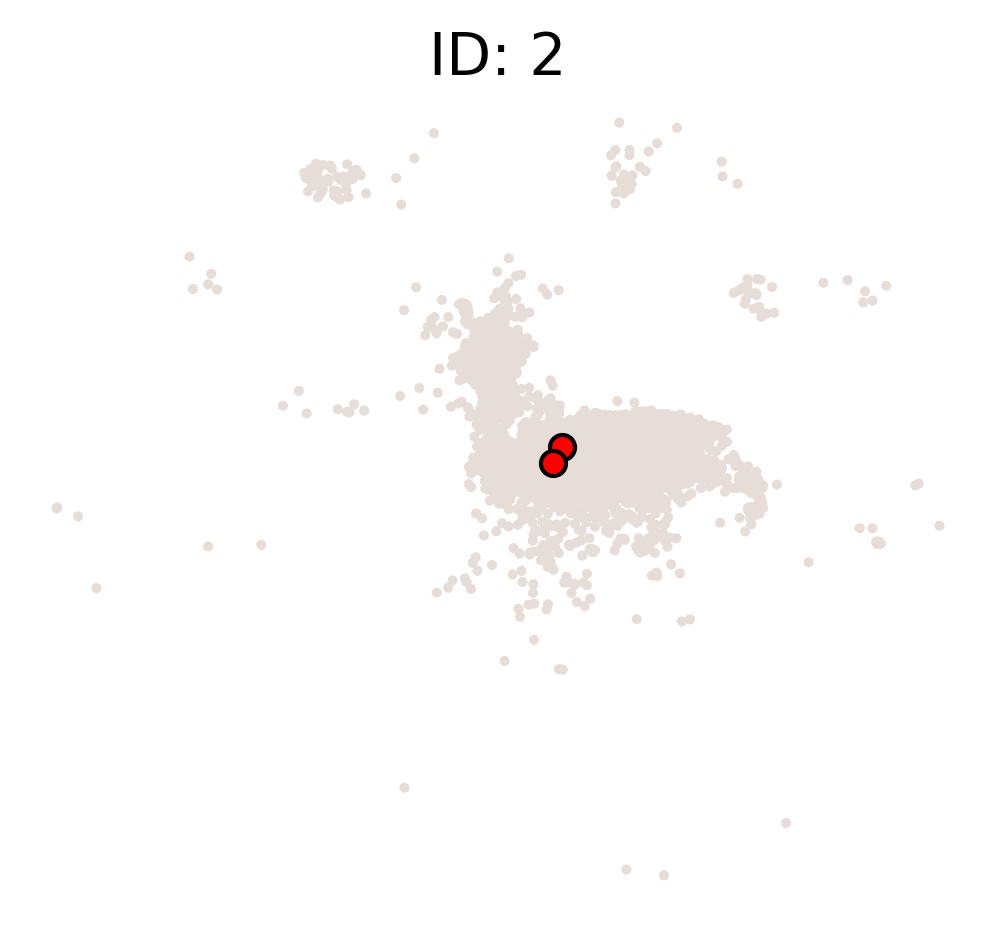

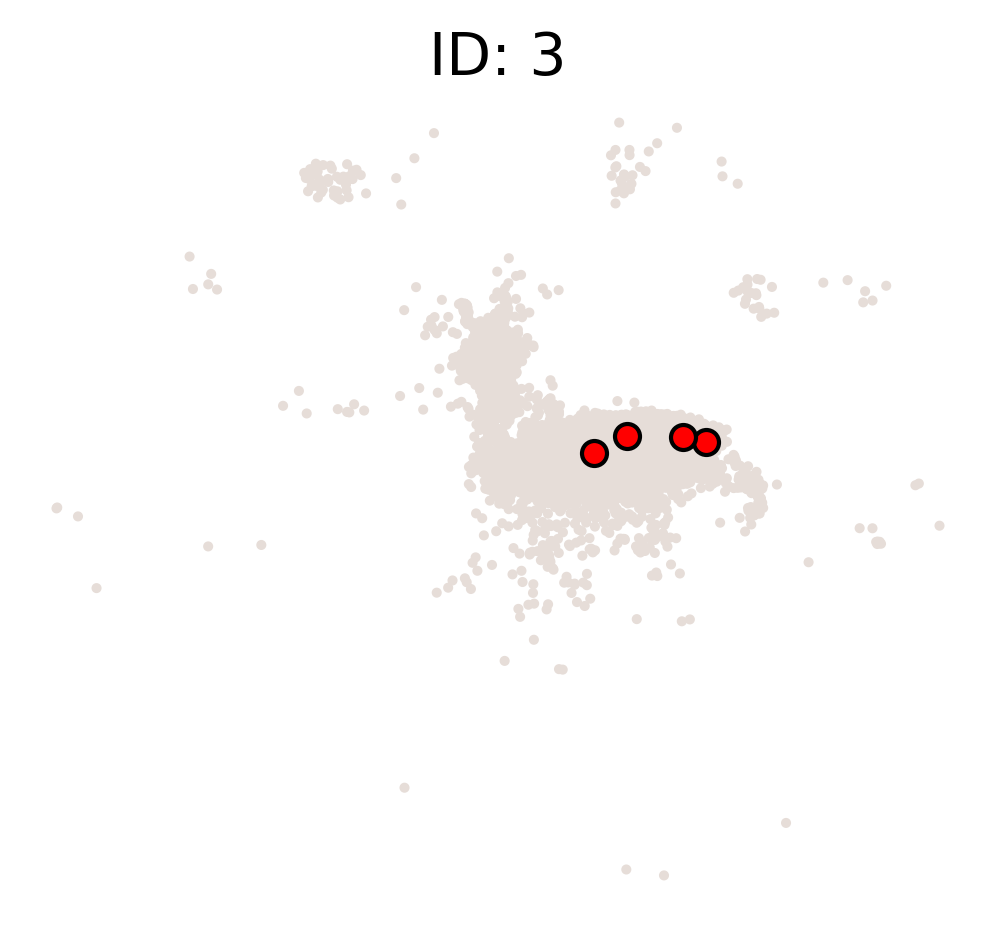

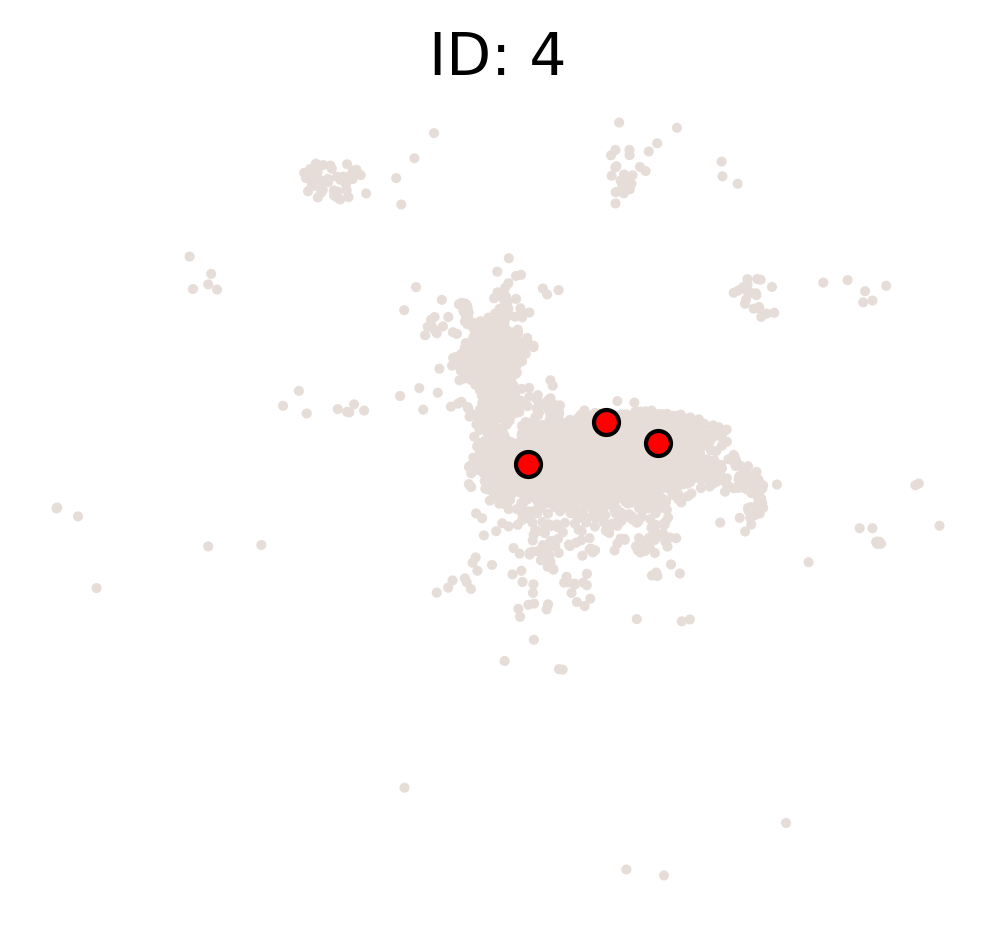

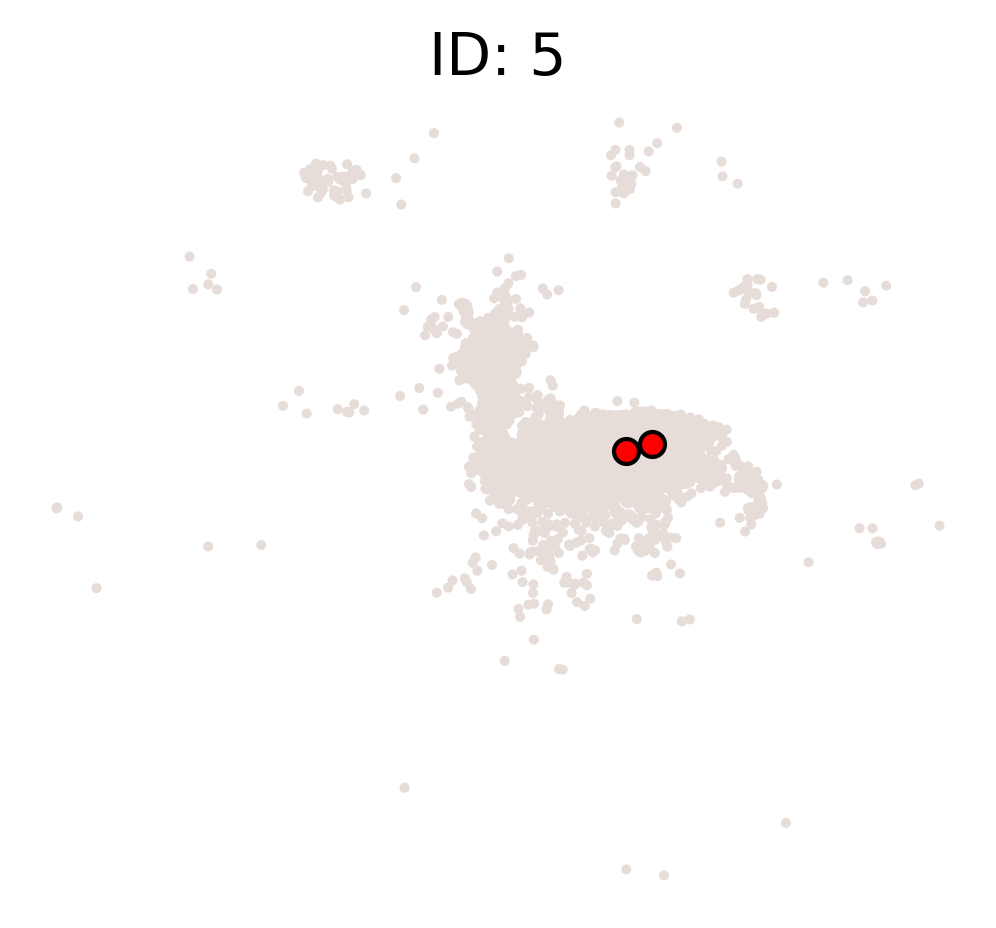

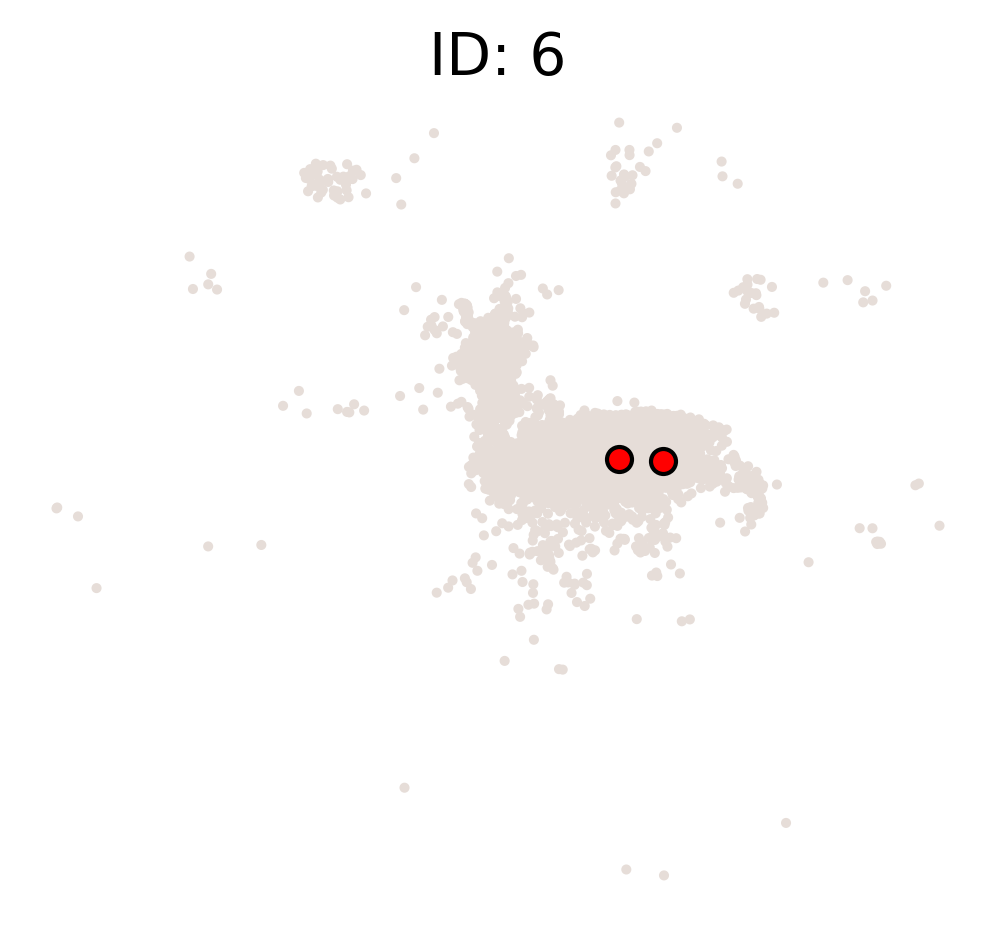

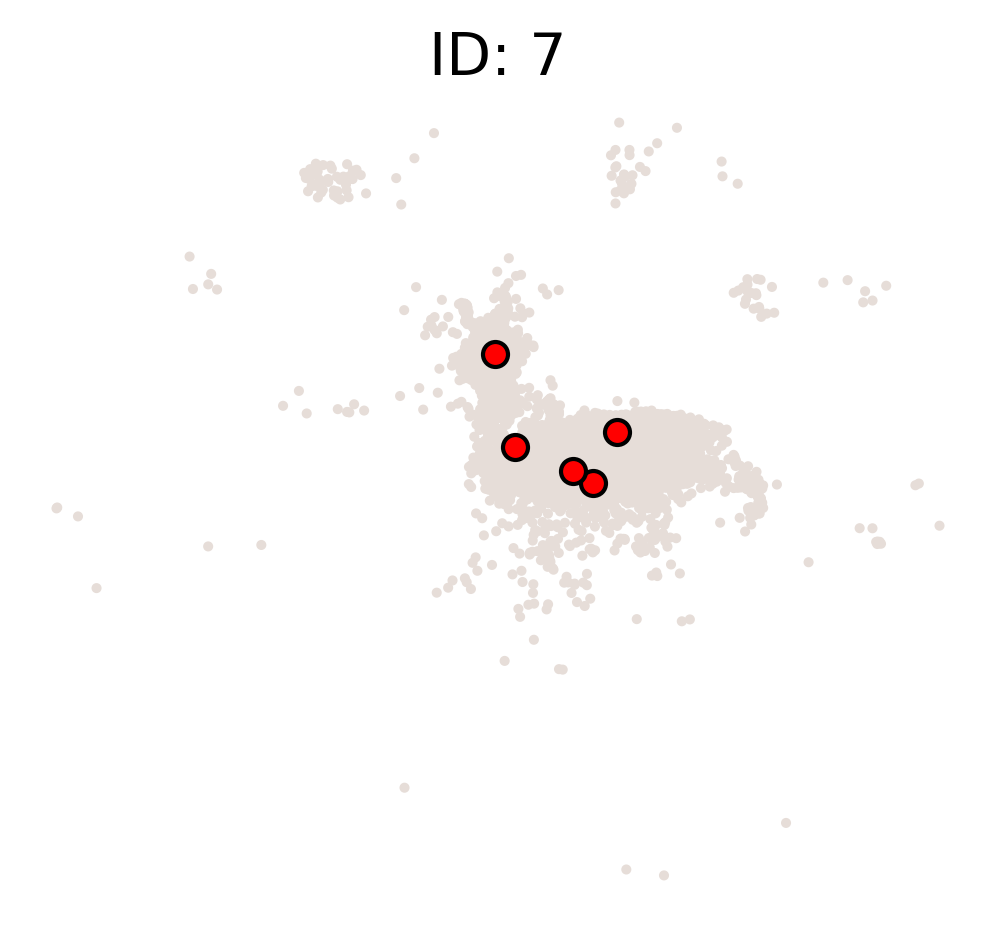

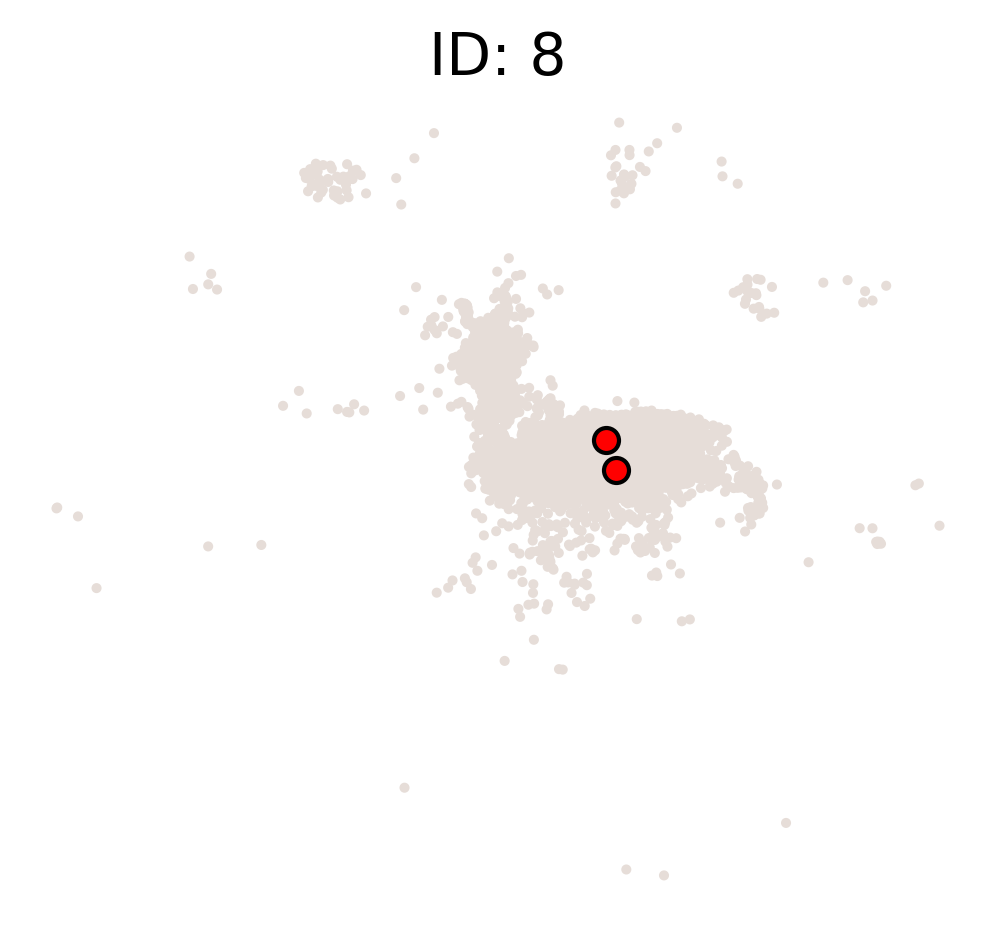

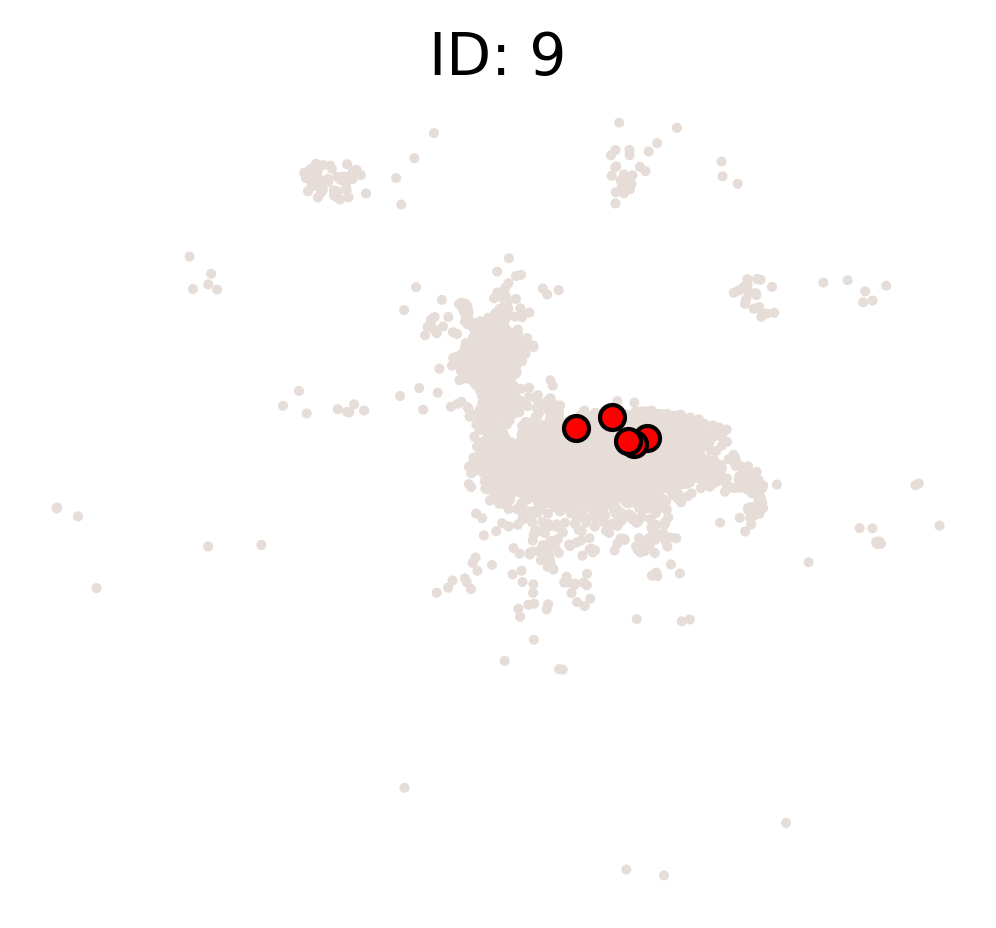

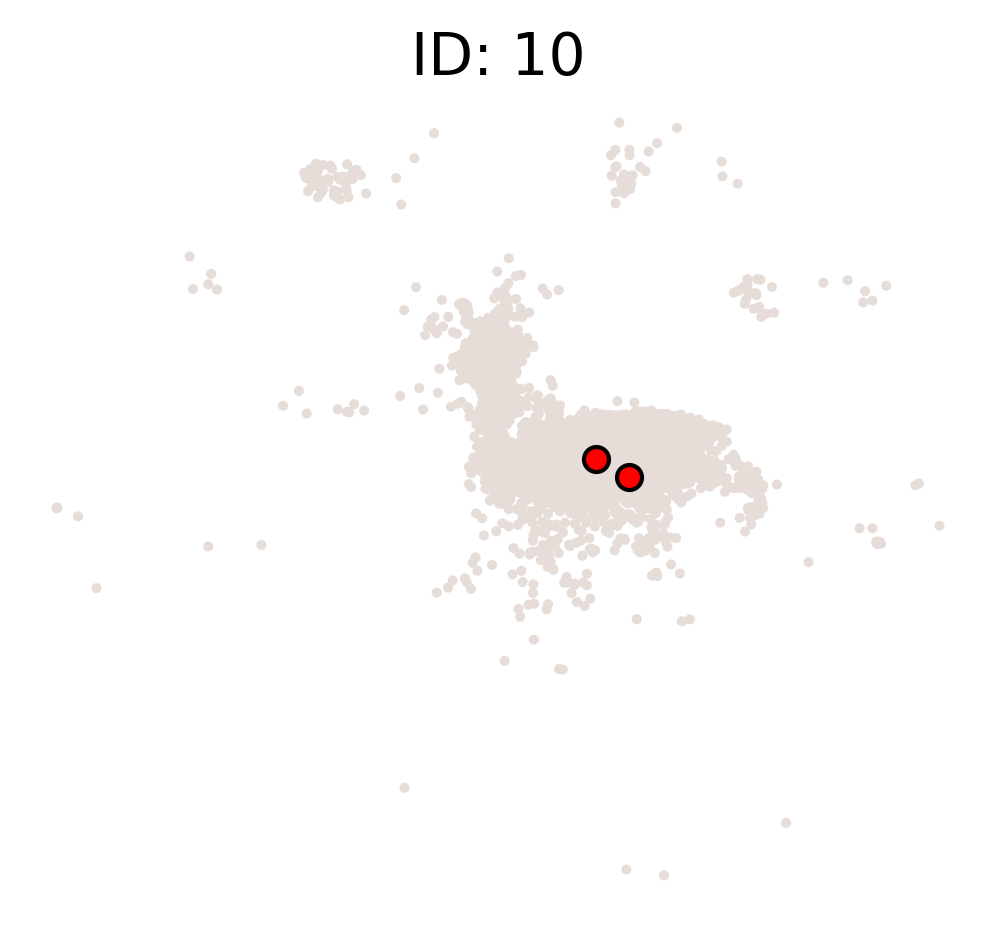

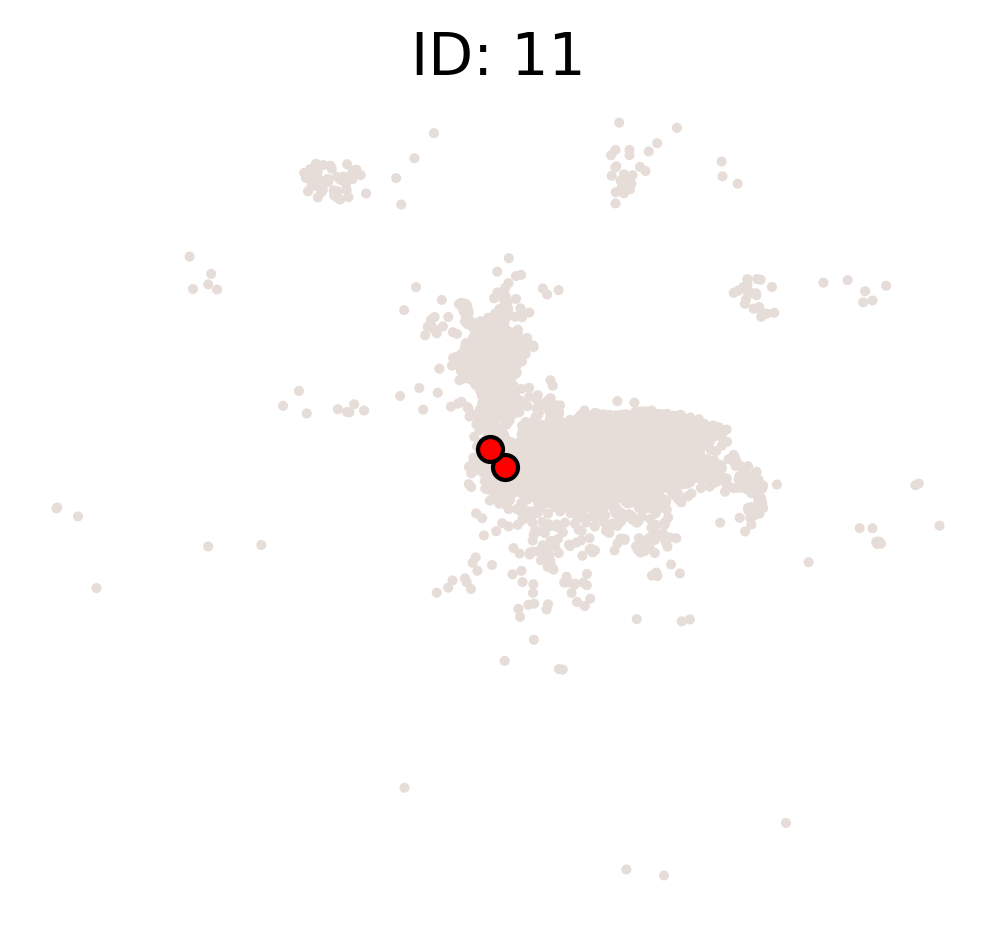

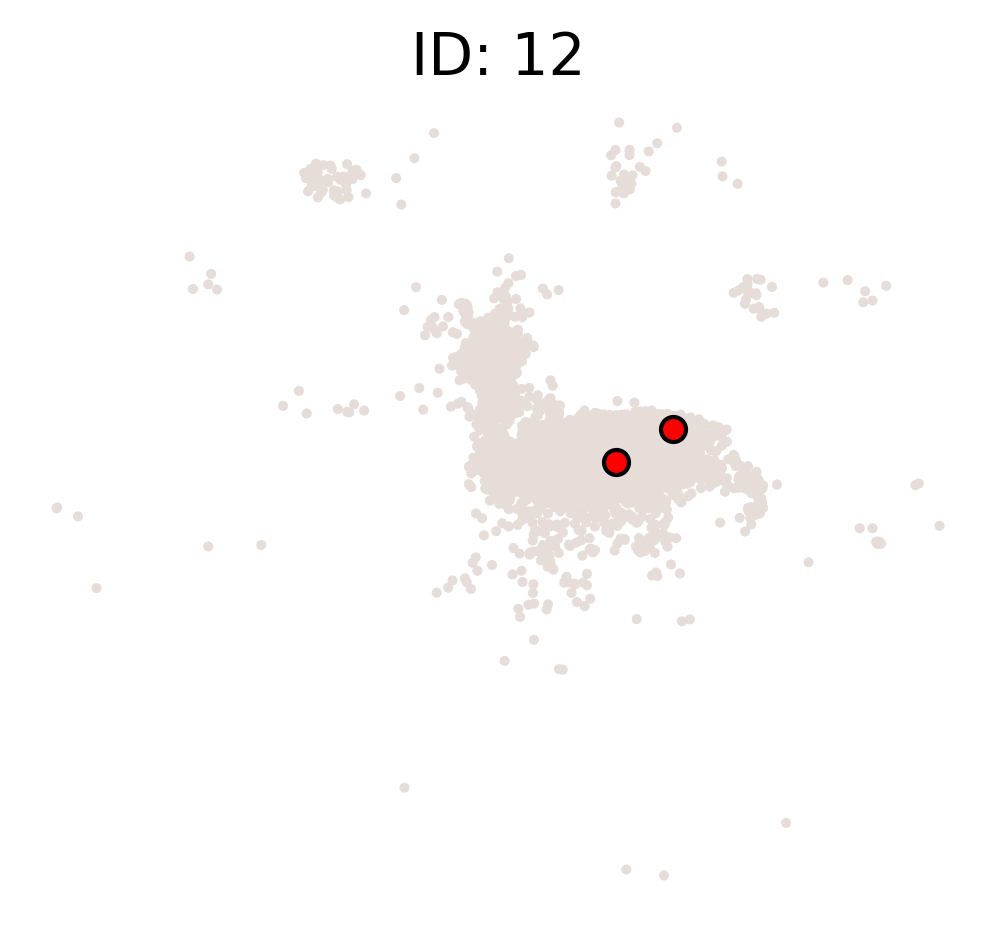

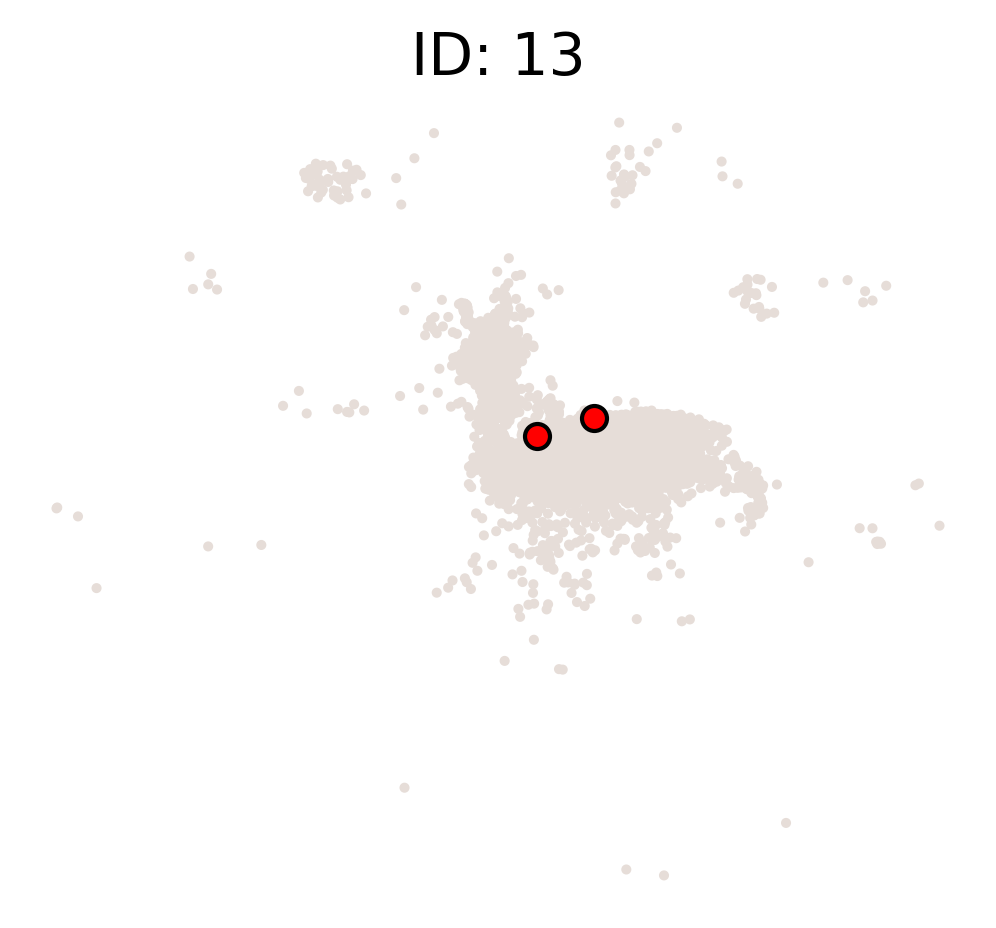

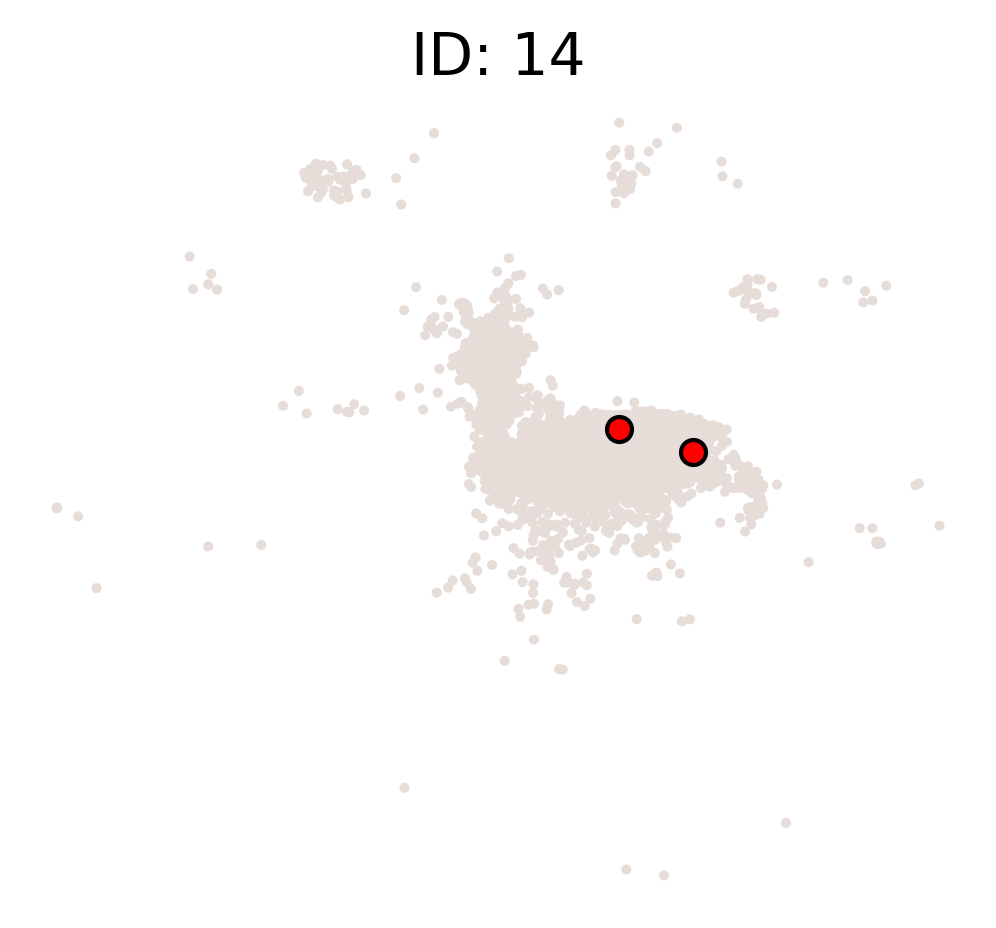

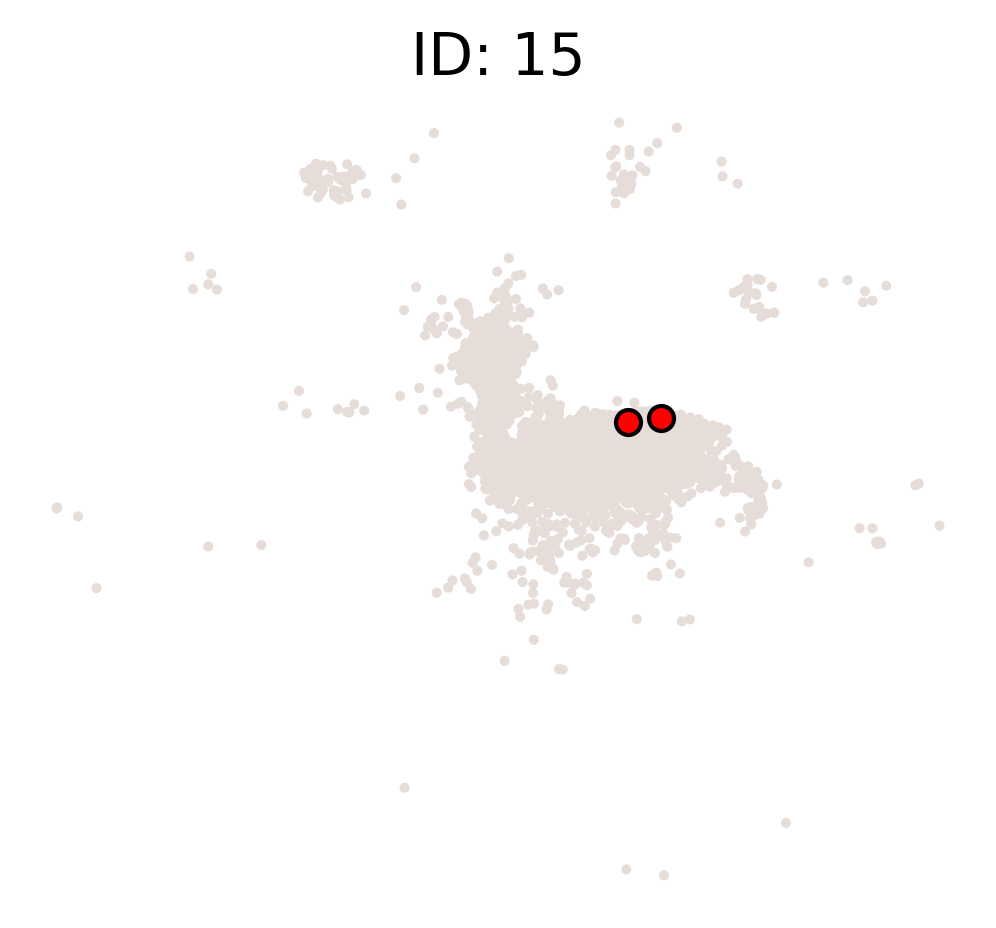

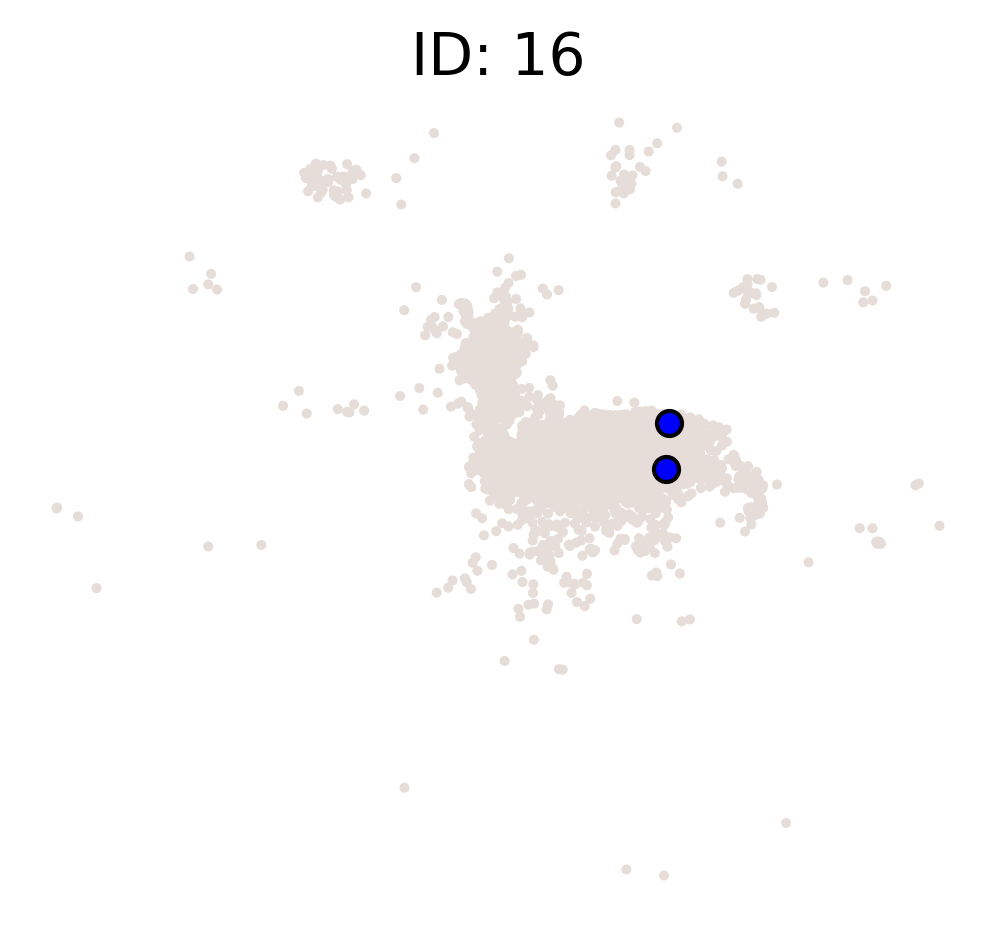

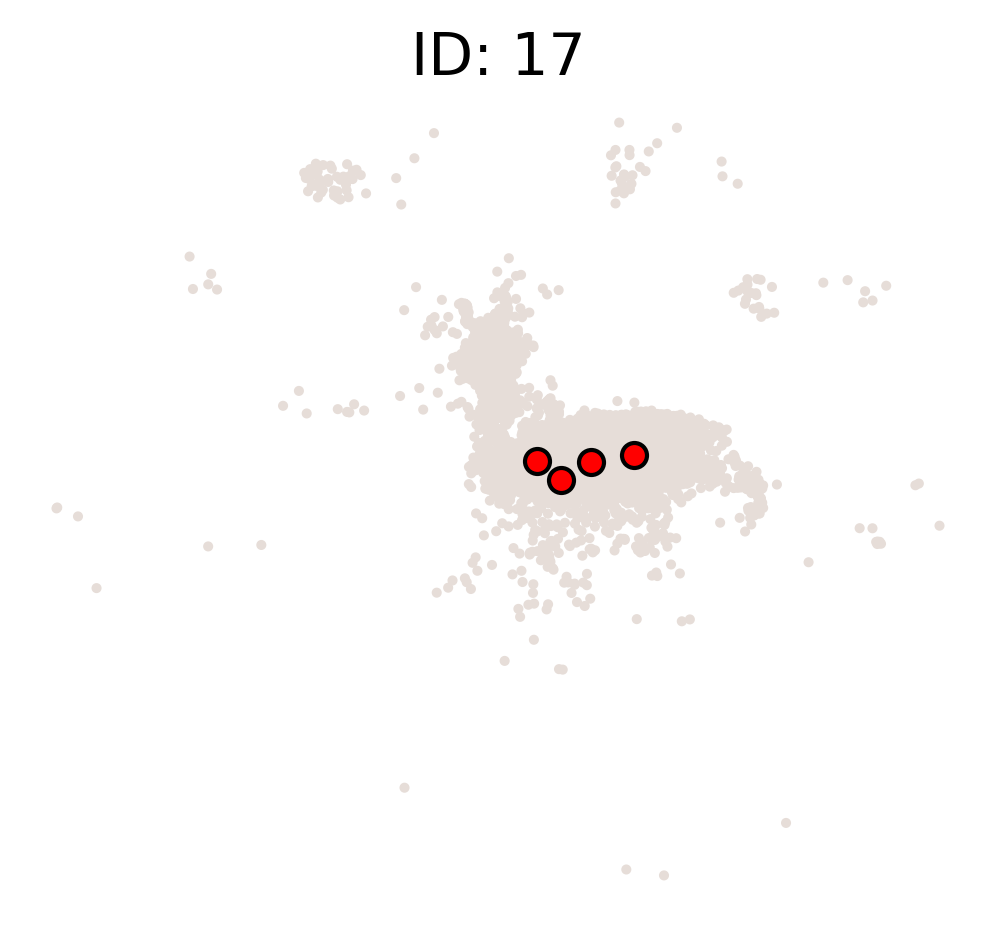

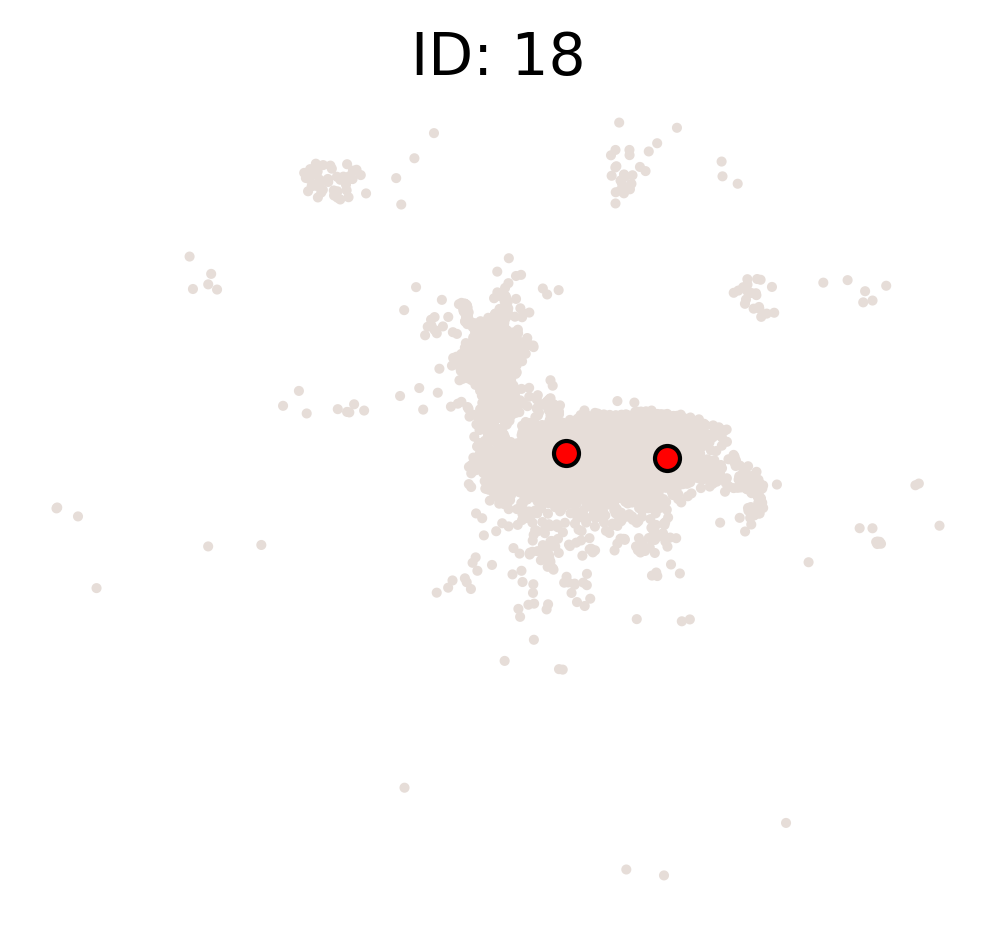

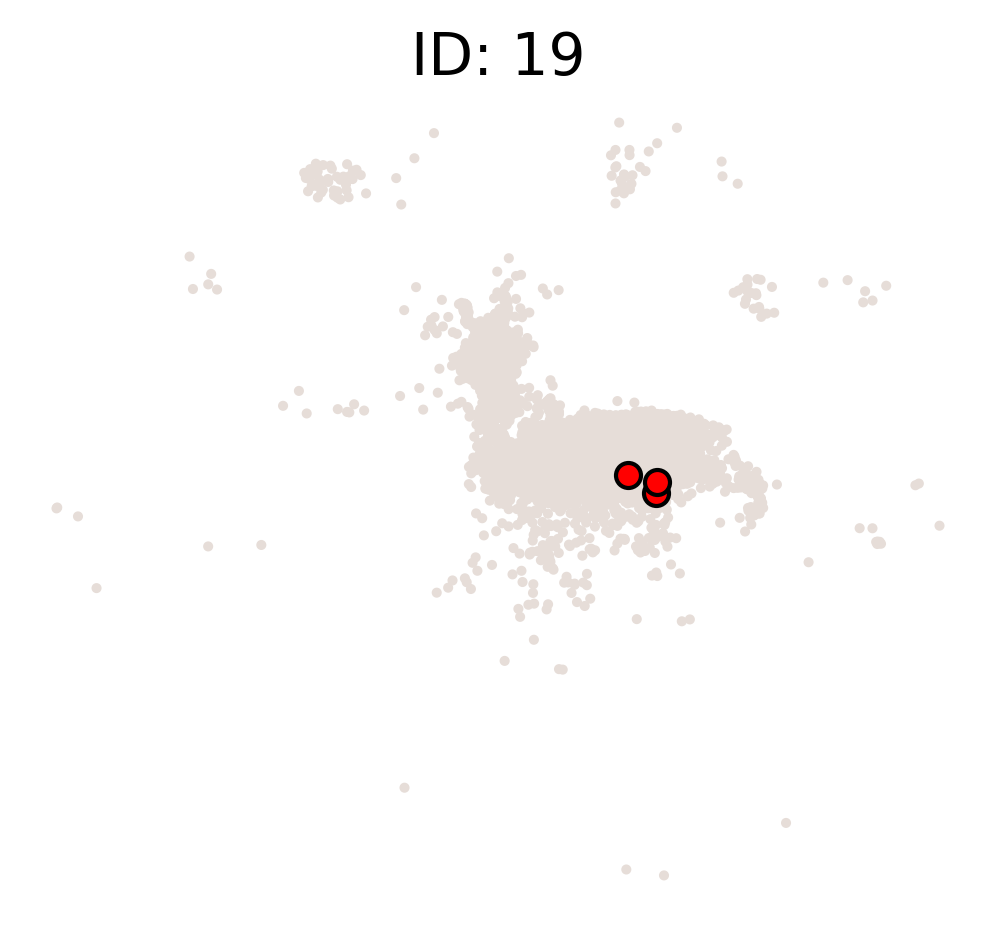

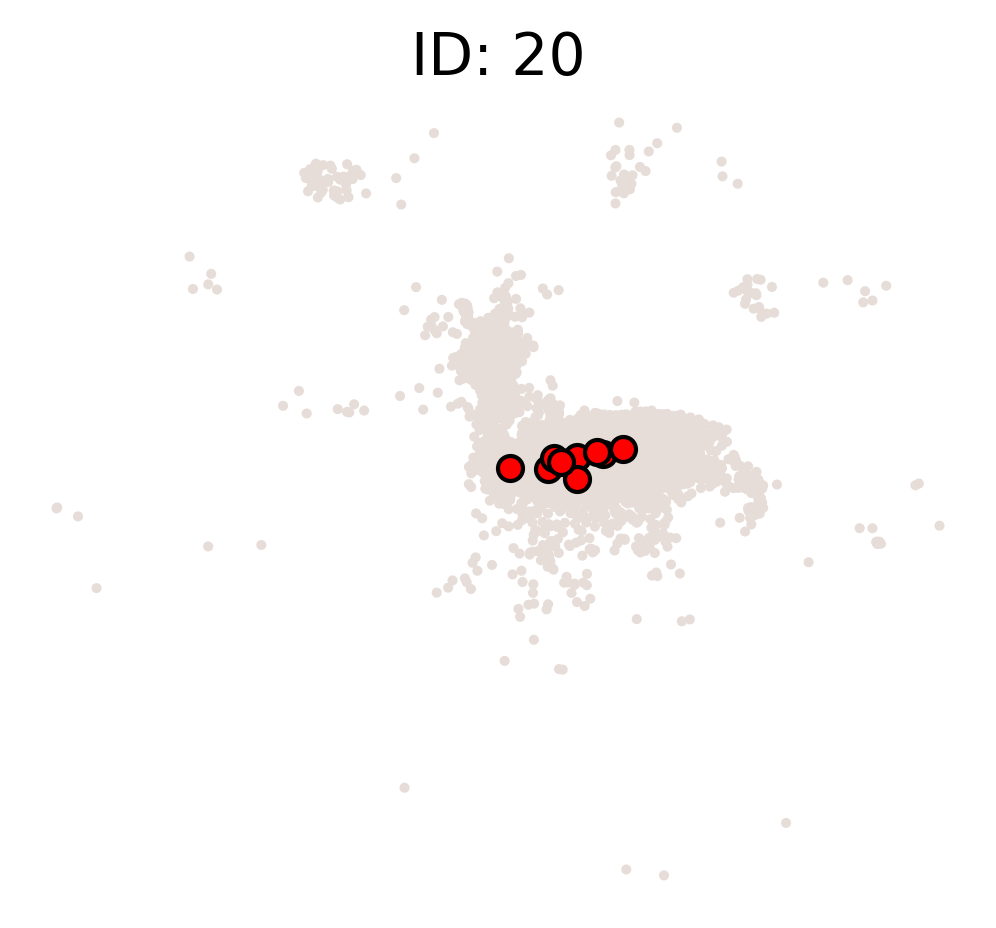

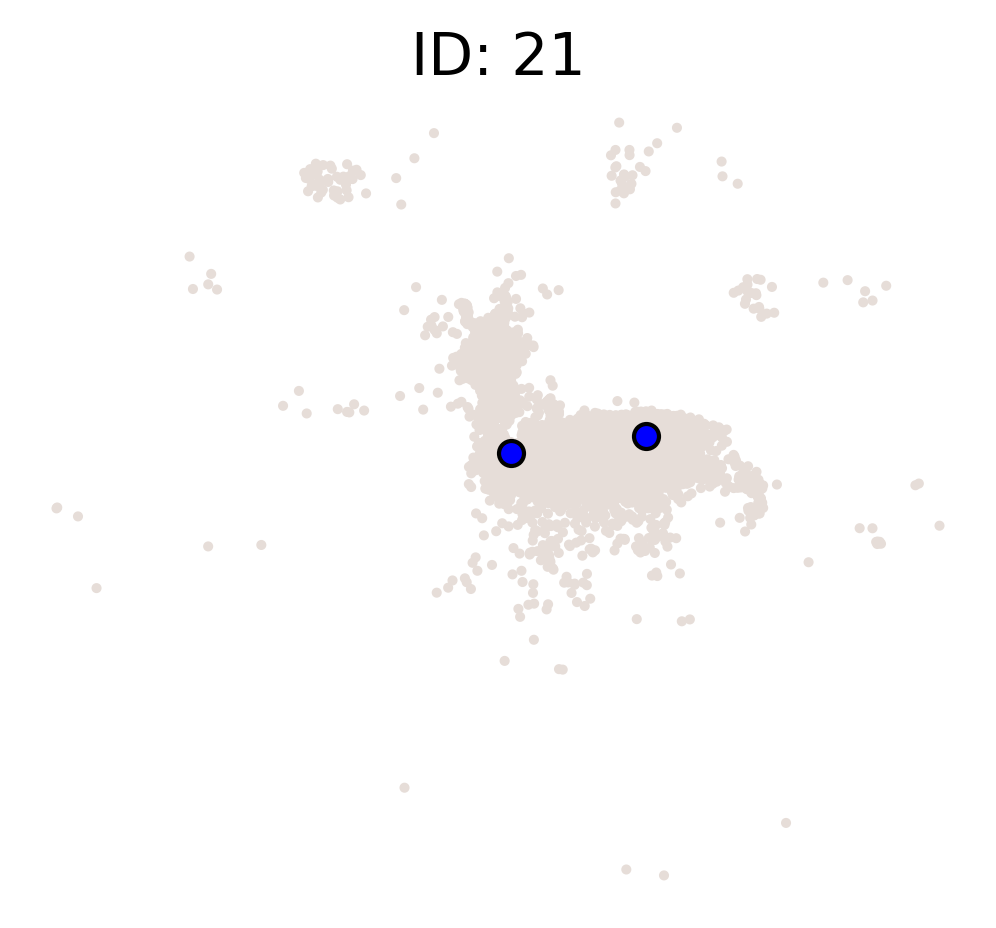

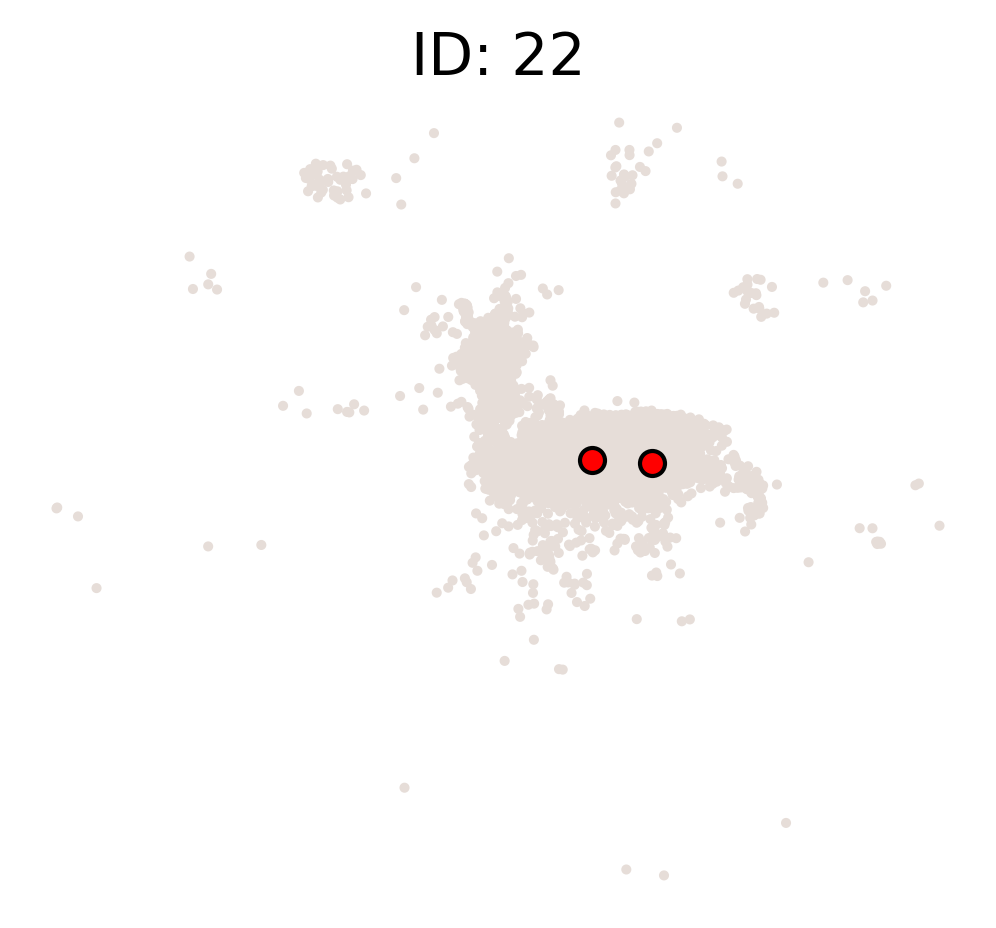

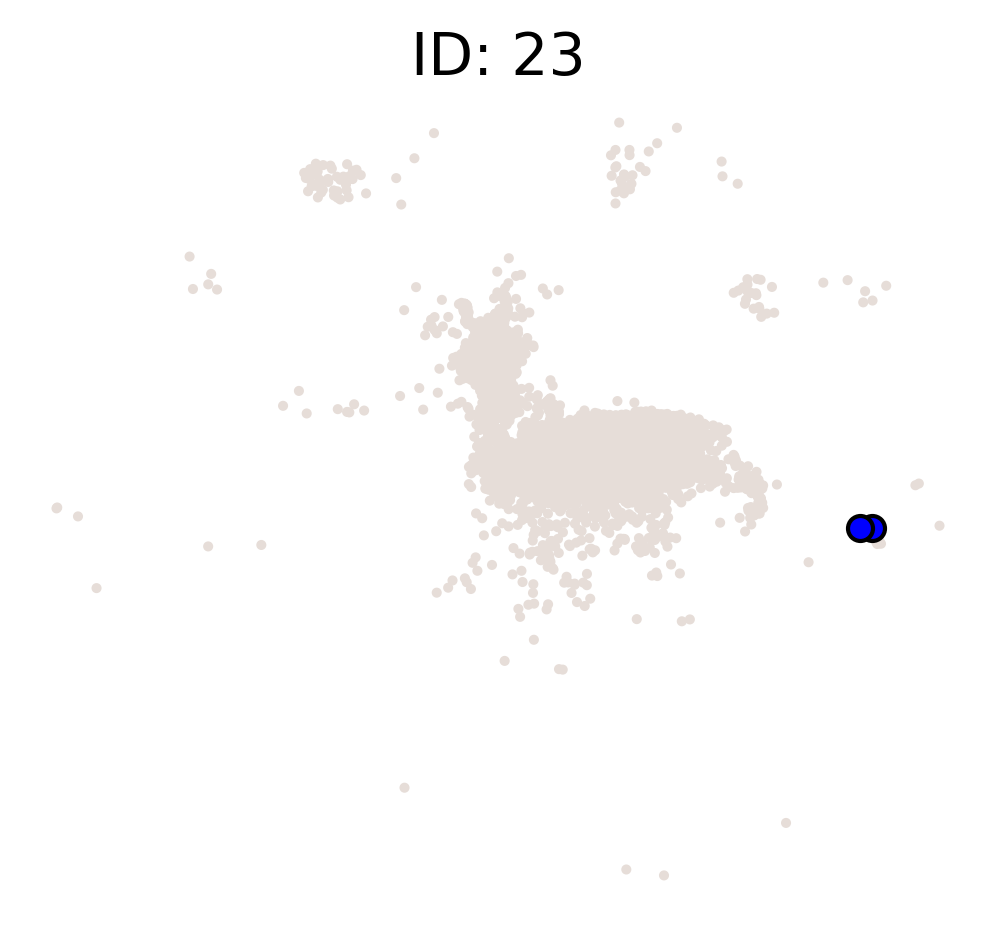

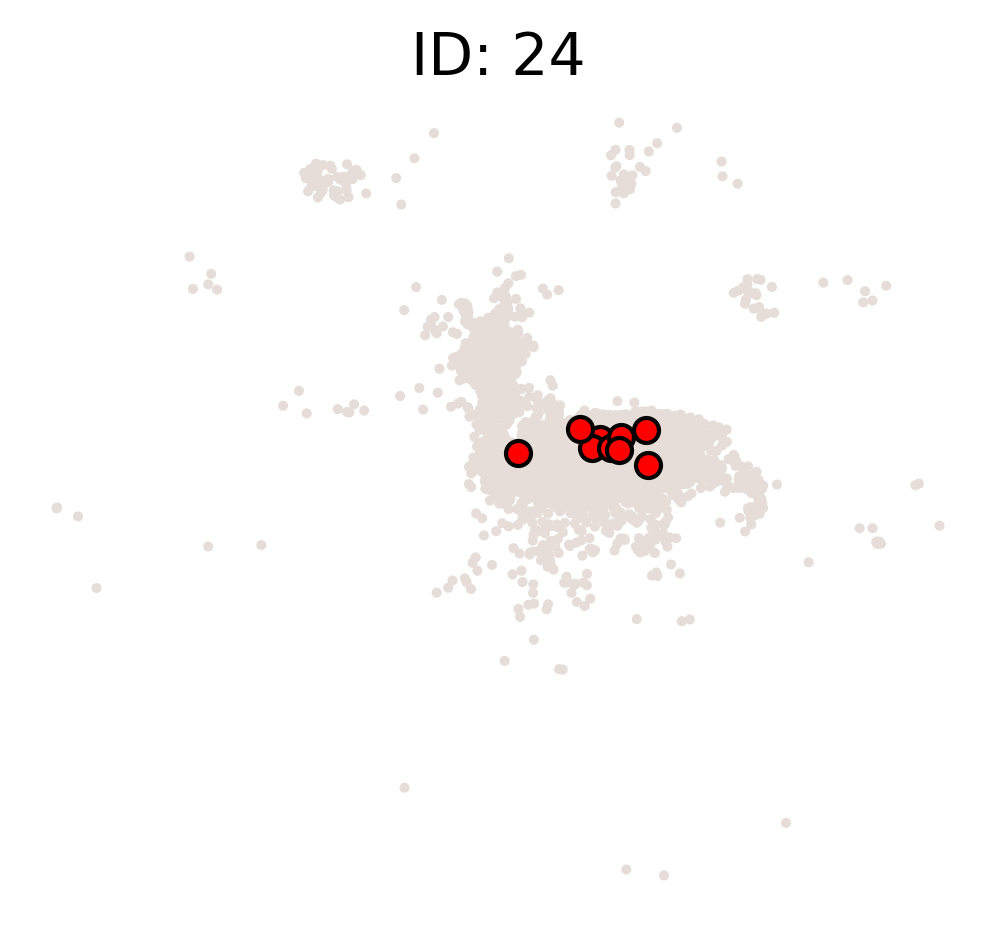

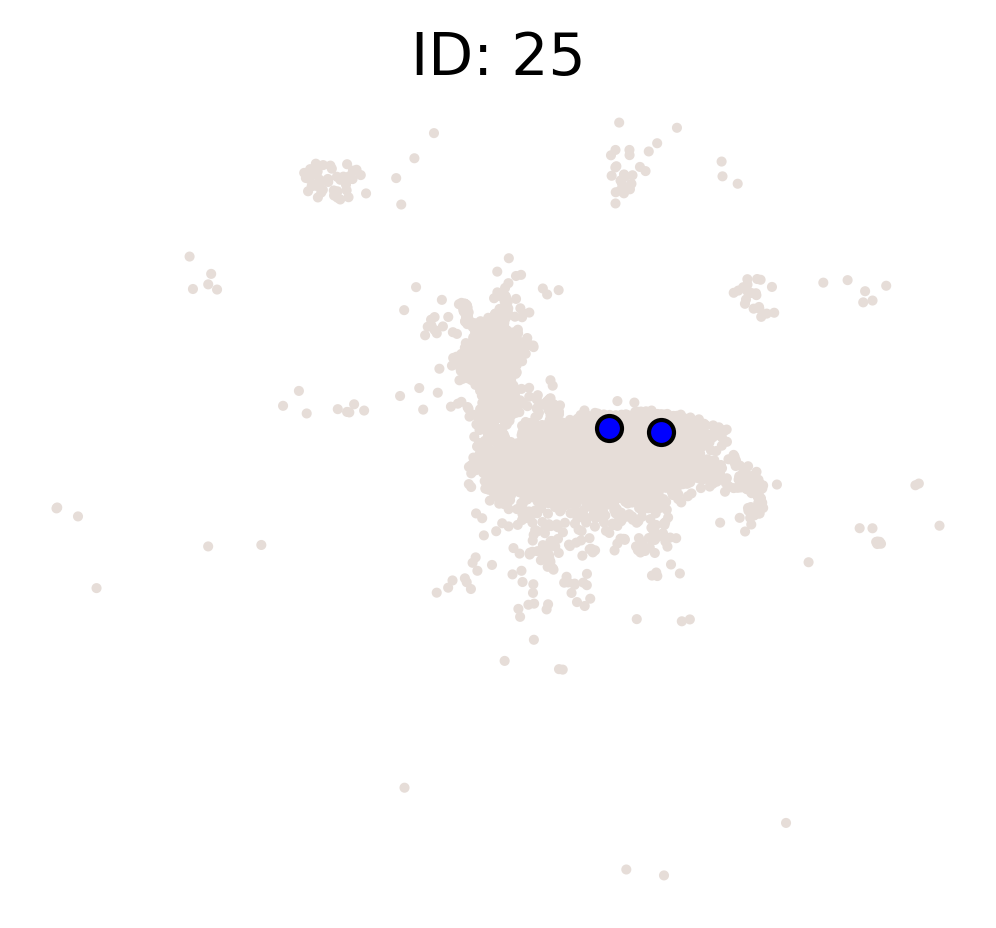

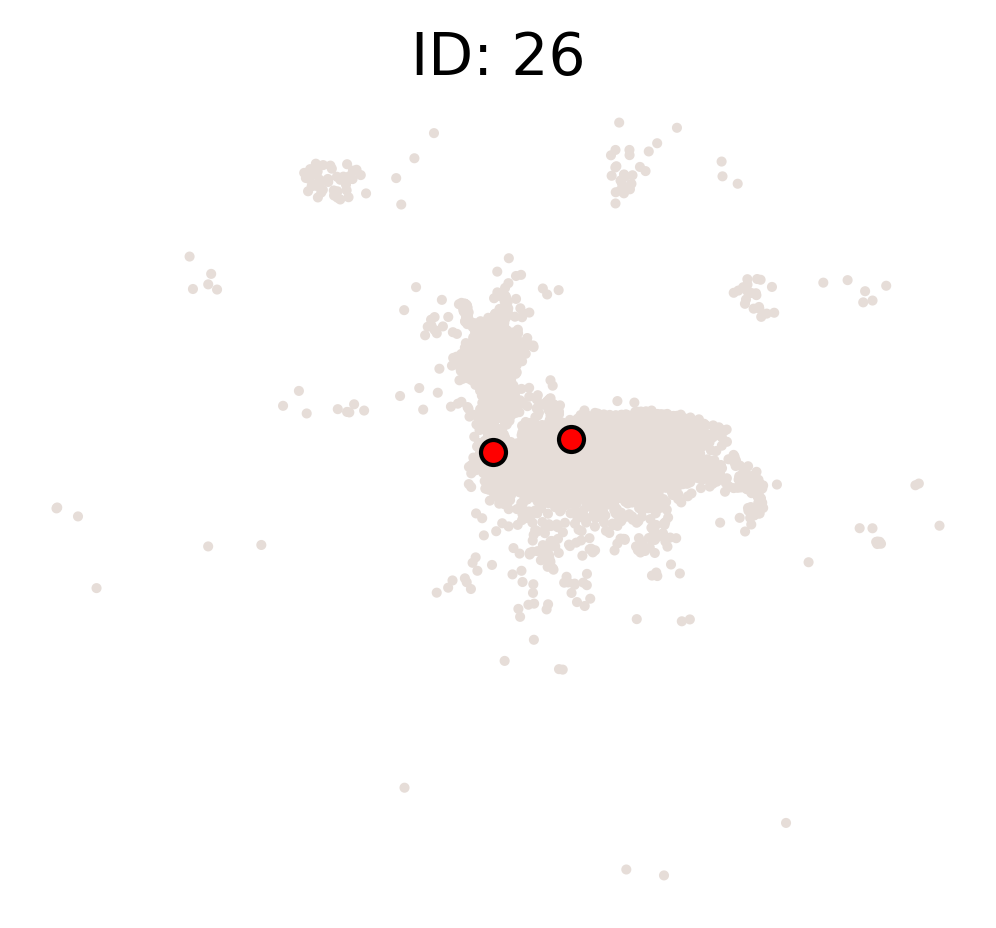

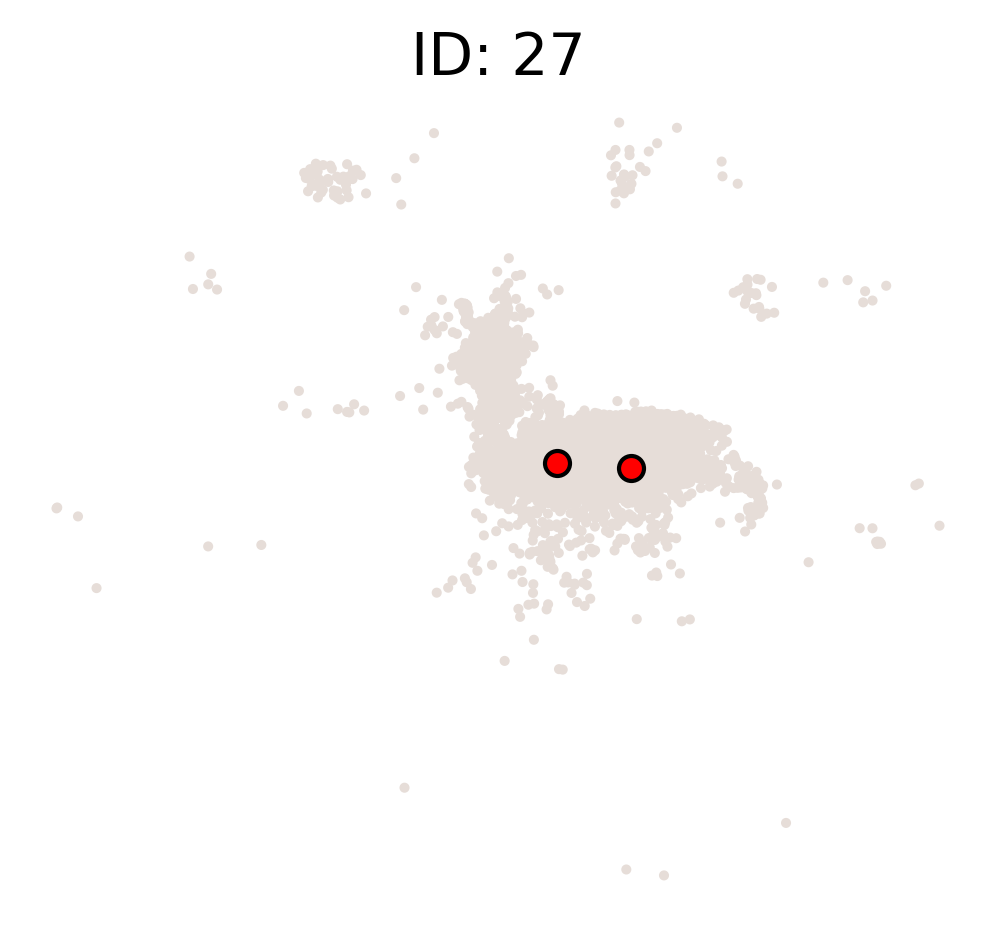

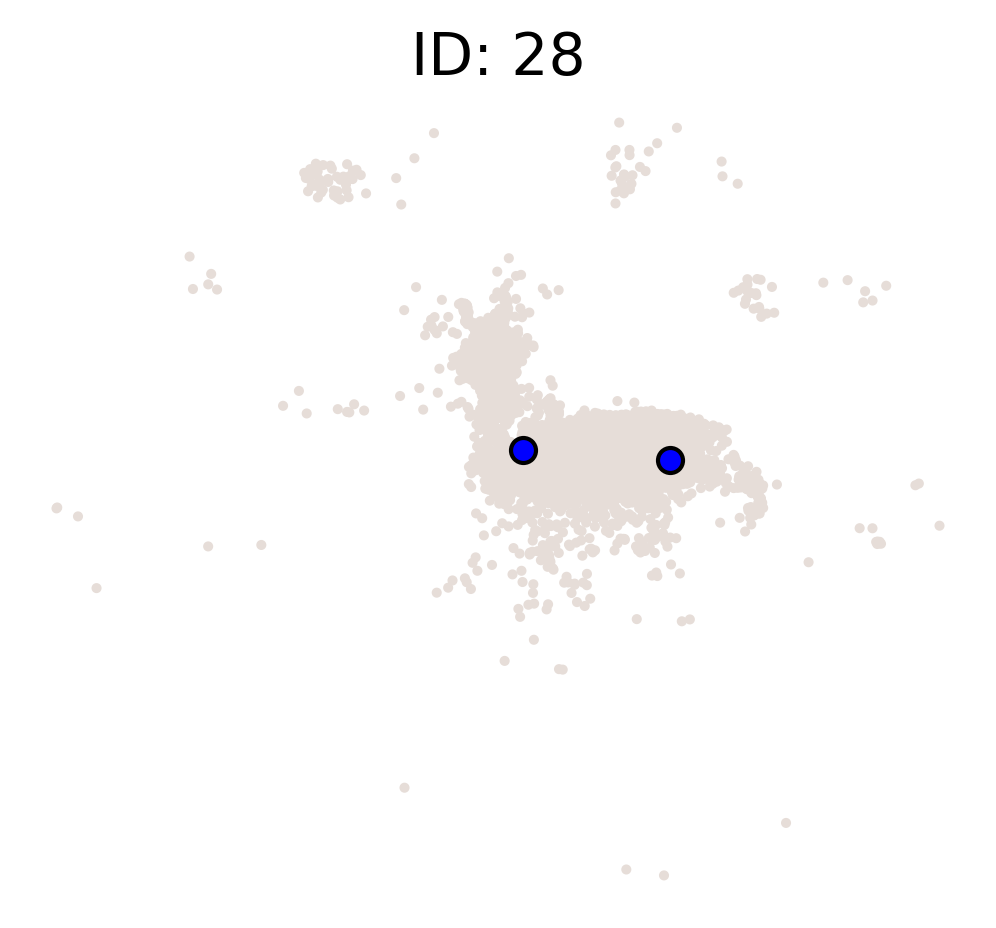

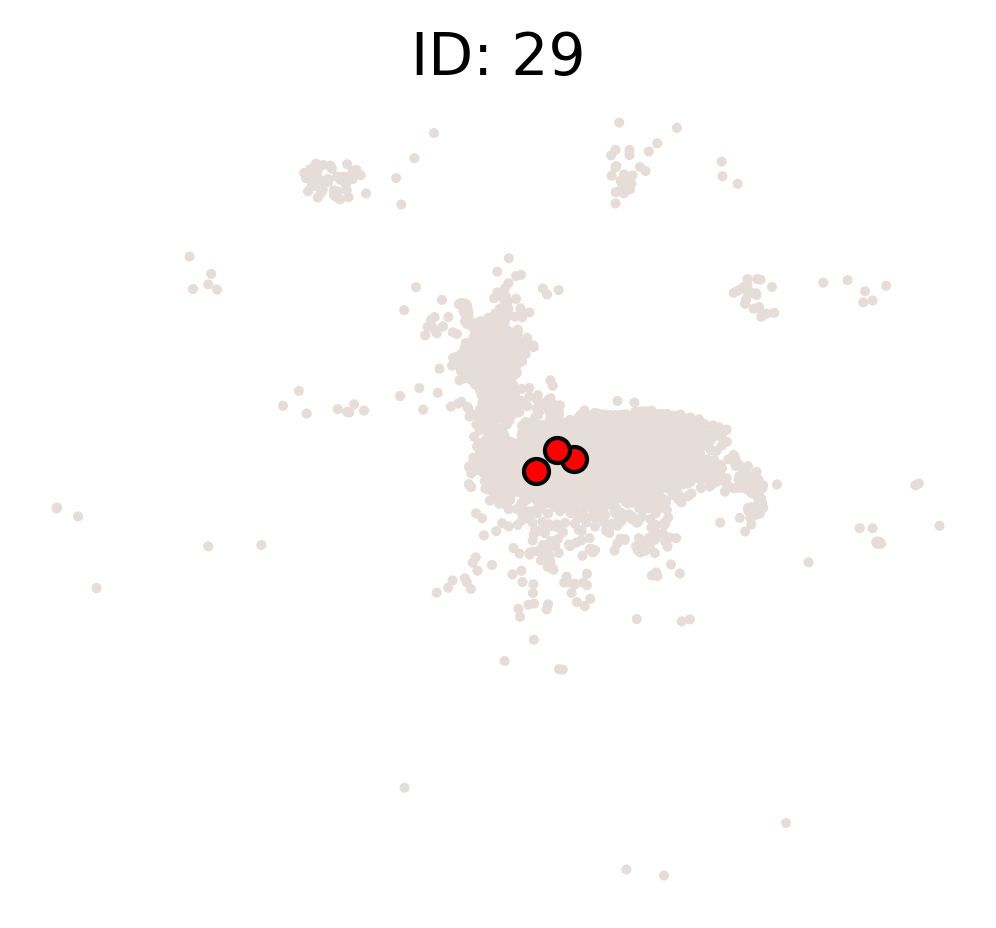

In [21]:
# Using range (works directly as an iterable of integers)
cs.pl.clones_on_manifold(adata_orig, selected_clone_list=range(0, 30))

Results saved as dictionary at adata.uns['fate_coupling_X_clone']


<AxesSubplot: title={'center': 'source: X_clone'}>

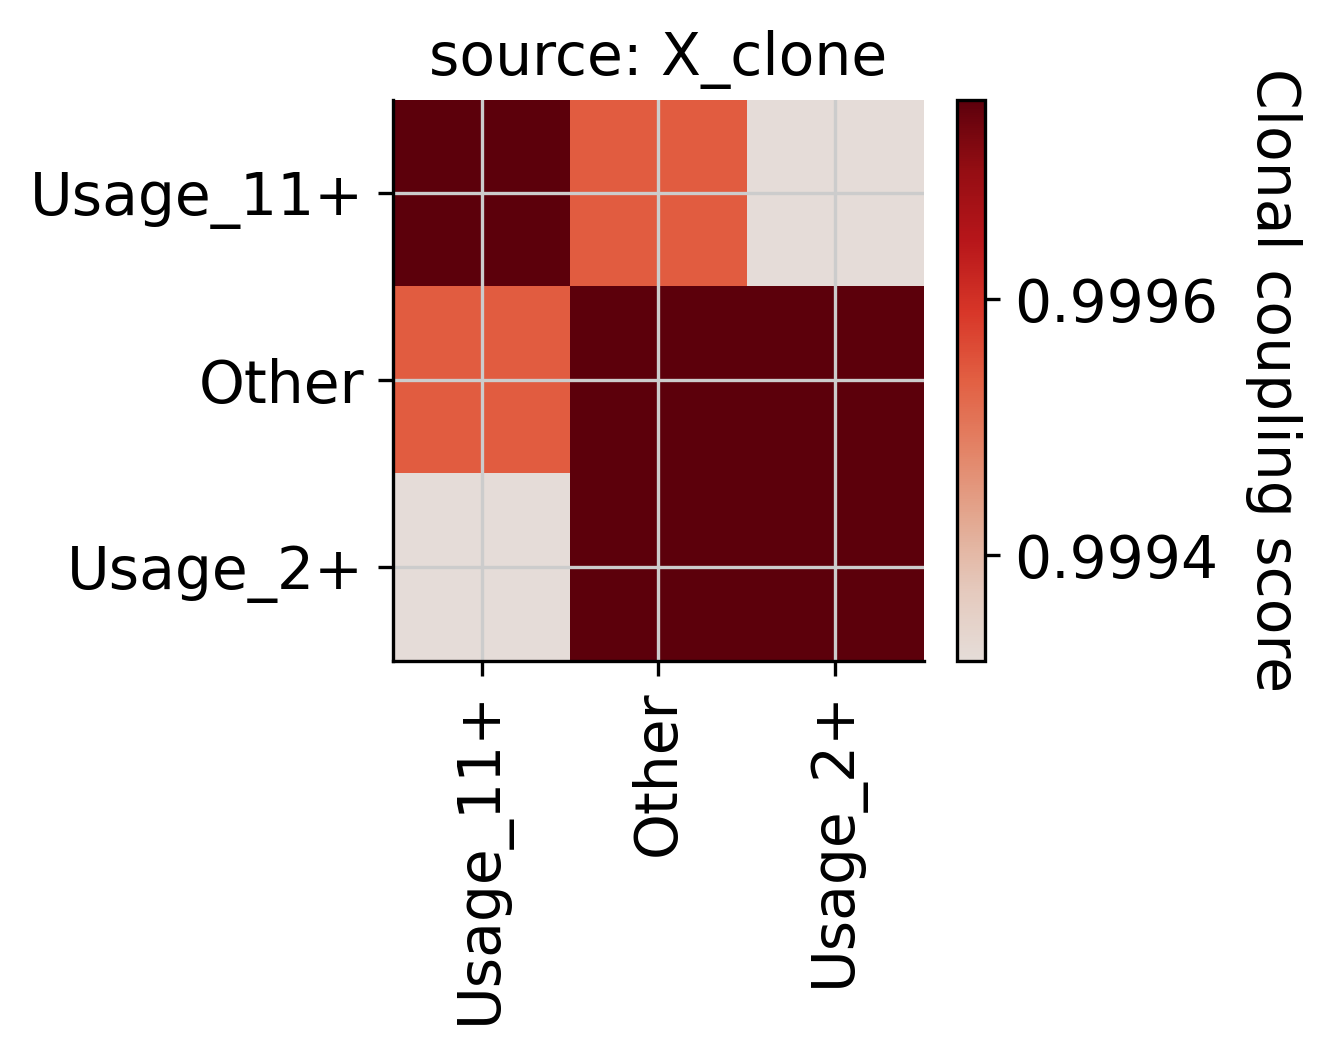

In [22]:
selected_times = "t0"
cs.tl.fate_coupling(
    adata_orig,
    source="X_clone",
#   selected_fates=selected_fates,
    selected_times=selected_times,
    normalize=False,
)
cs.pl.fate_coupling(adata_orig, source="X_clone")


Results saved as dictionary at adata.uns['fate_coupling_X_clone']


<AxesSubplot: title={'center': 'source: X_clone'}>

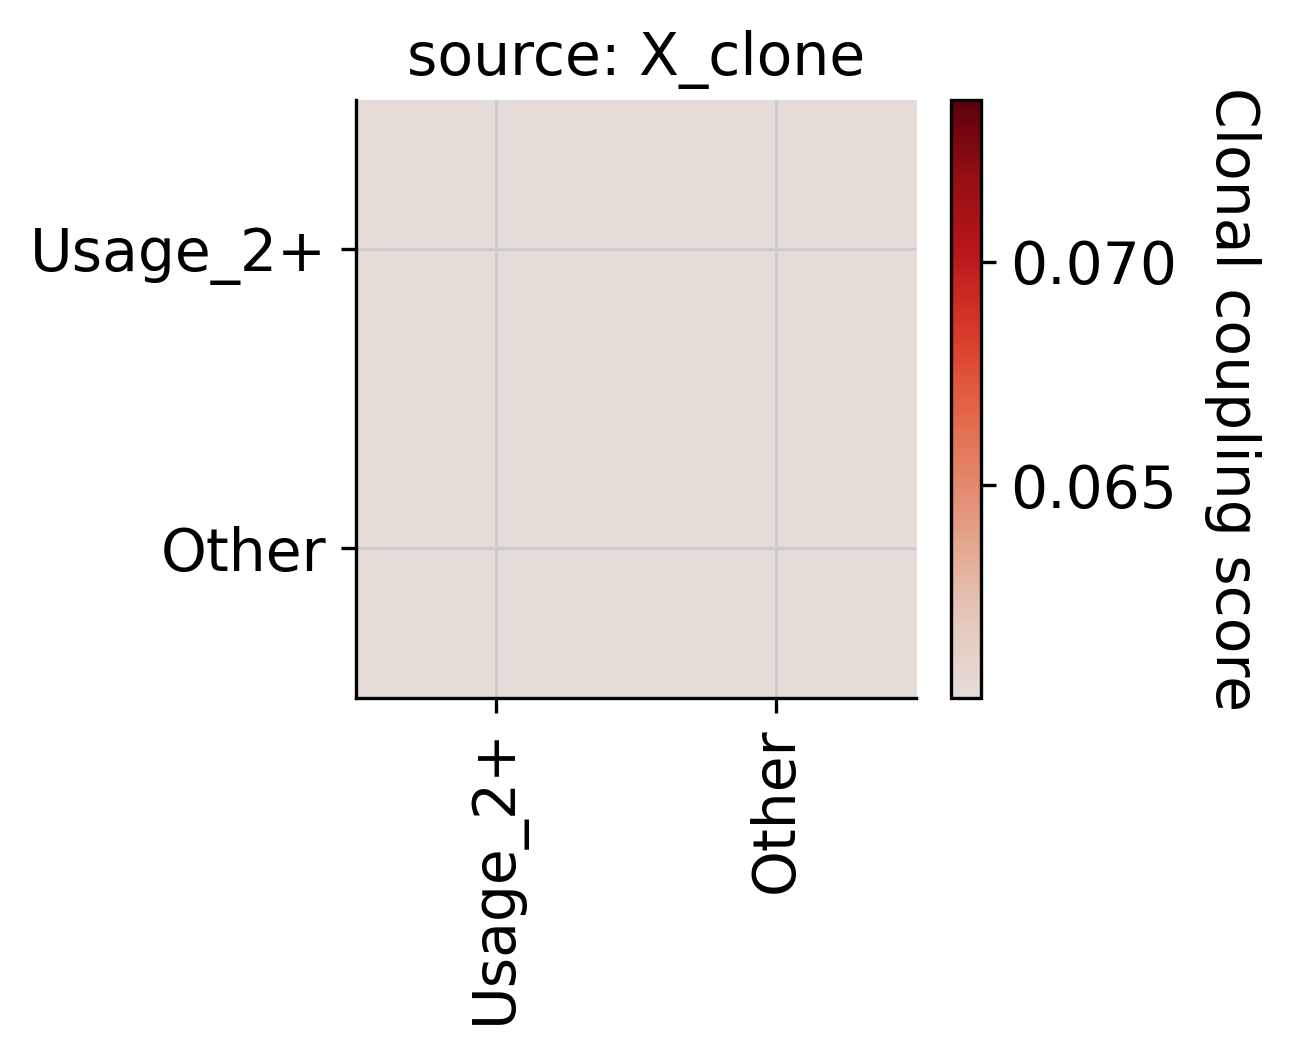

In [23]:
selected_times = "t1"
cs.tl.fate_coupling(
    adata_orig,
    source="X_clone",
#   selected_fates=selected_fates,
    selected_times=selected_times,
    normalize=False,
)
cs.pl.fate_coupling(adata_orig, source="X_clone")


Data saved at adata.uns['barcode_heatmap']


<AxesSubplot: title={'center': '110 clones'}>

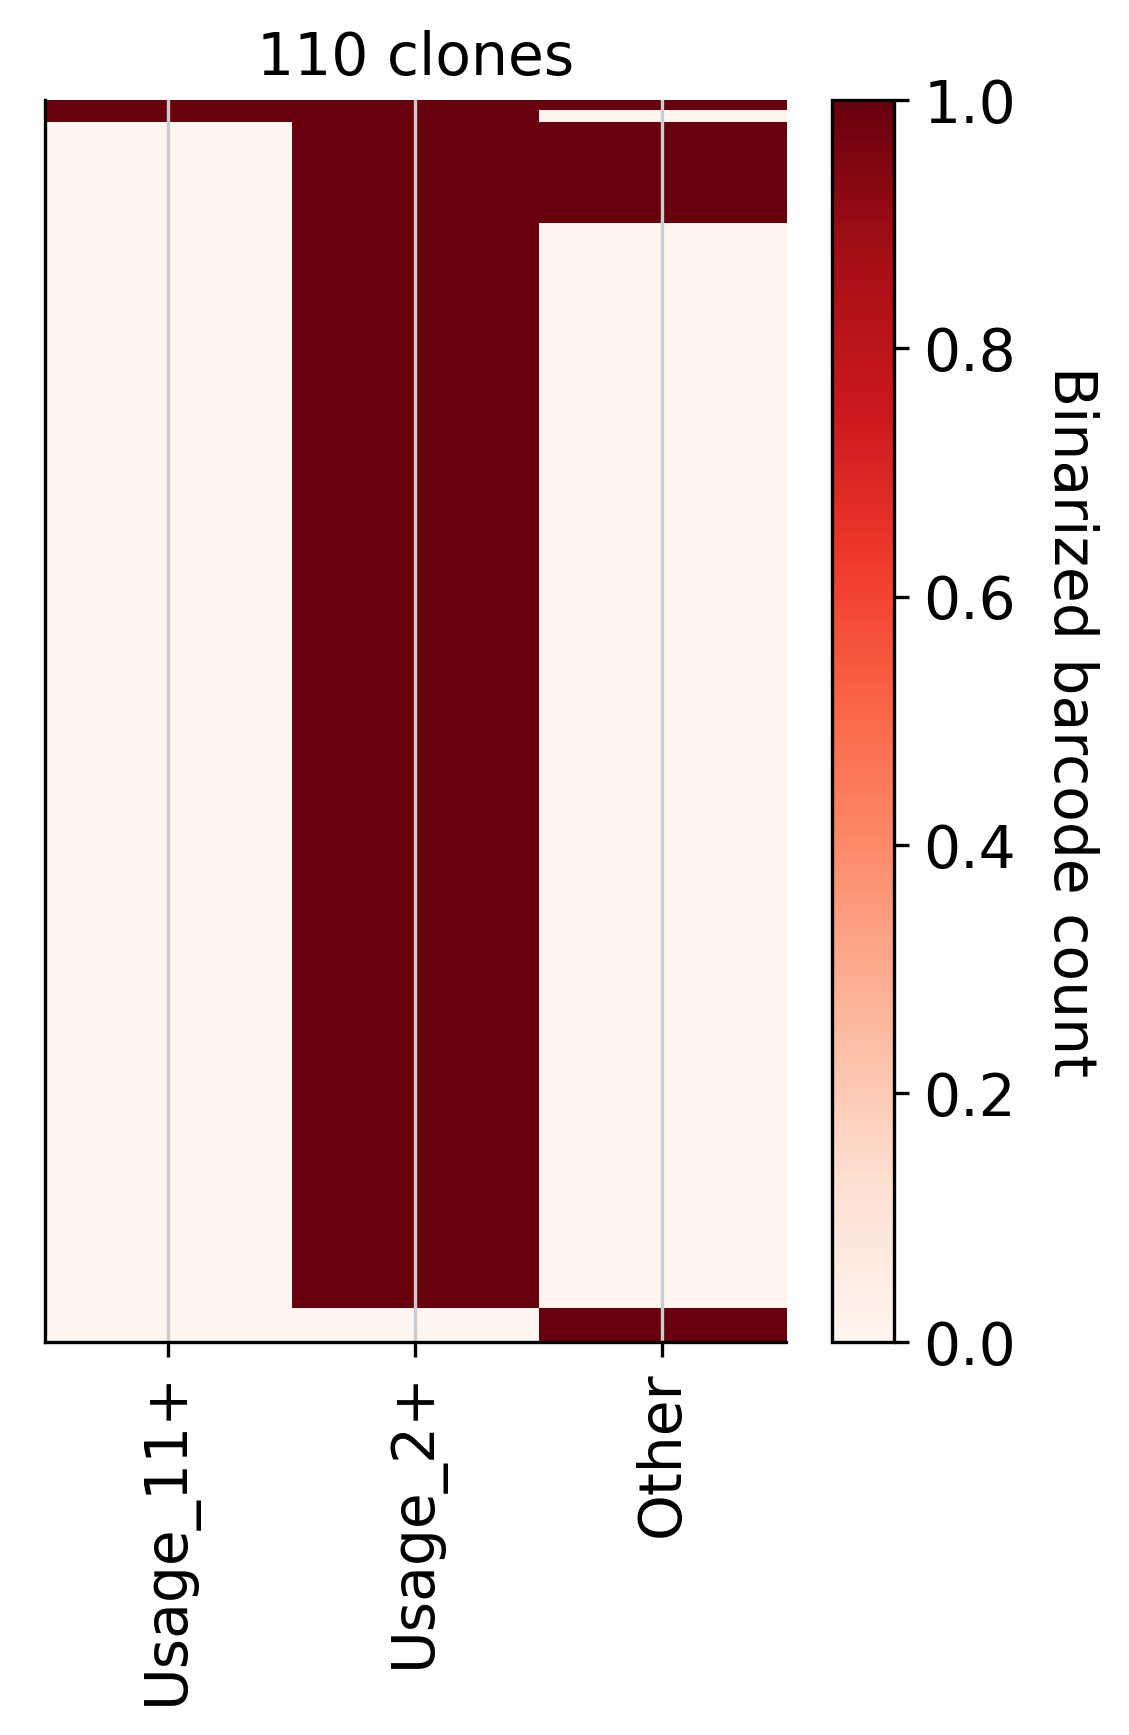

In [24]:
selected_times = ["t0","t1"]
cs.pl.barcode_heatmap(
    adata_orig,
    selected_times=selected_times,binarize=True,
    color_bar=True,
)

In [29]:
adata = cs.tmap.infer_Tmap_from_multitime_clones(
    adata_orig,
    clonal_time_points=["t0", "t1"],
    later_time_point="t1",
    smooth_array=[20, 15, 10],
    sparsity_threshold=0.2,
    max_iter_N=3,
)

------Compute the full Similarity matrix if necessary------
------Infer transition map between initial time points and the later time one------
--------Current initial time point: t0--------
Step 1: Select time points
Number of multi-time clones post selection: 3
Step 2: Optimize the transition map recursively
Load pre-computed similarity matrix
Iteration 1, Use smooth_round=20
Iteration 2, Use smooth_round=15
Iteration 3, Use smooth_round=10
Convergence (CoSpar, iter_N=3): corr(previous_T, current_T)=0.958
-----------Total used time: 9.74918270111084 s ------------


Results saved at adata.obs['fate_map_transition_map_Usage_2+']


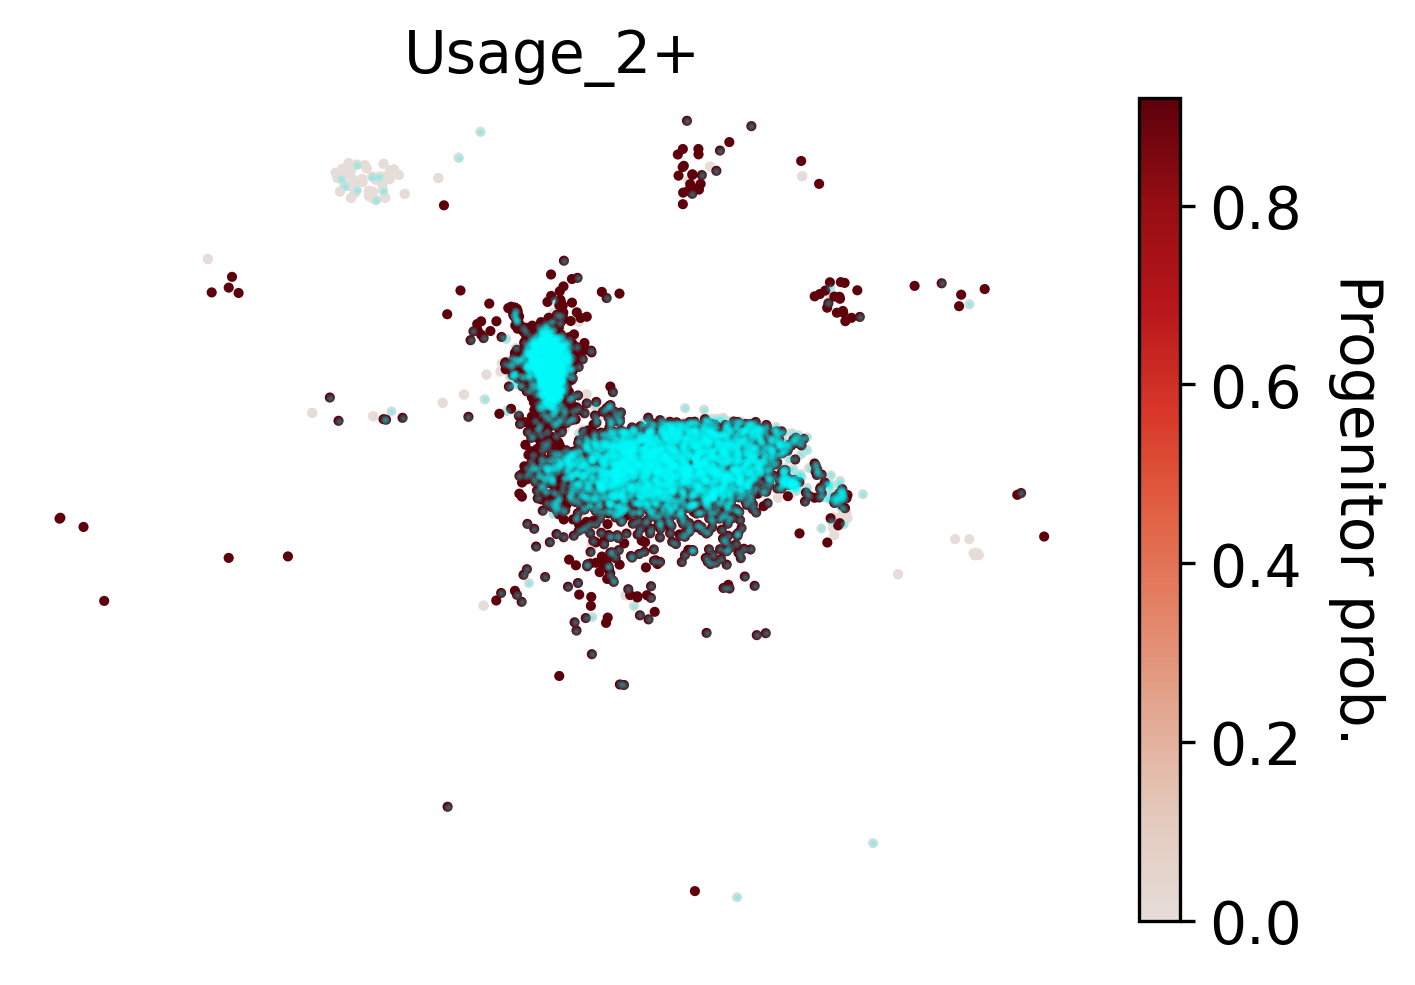

In [30]:
cs.tl.fate_map(
    adata,
    selected_fates=["Usage_2+"],
    source="transition_map",
    map_backward=True,
)
cs.pl.fate_map(
    adata,
    selected_fates=["Usage_2+"],
    source="transition_map",
    plot_target_state=True,
    show_histogram=False,
)



Results saved at adata.obs['fate_map_transition_map_Usage_11+']


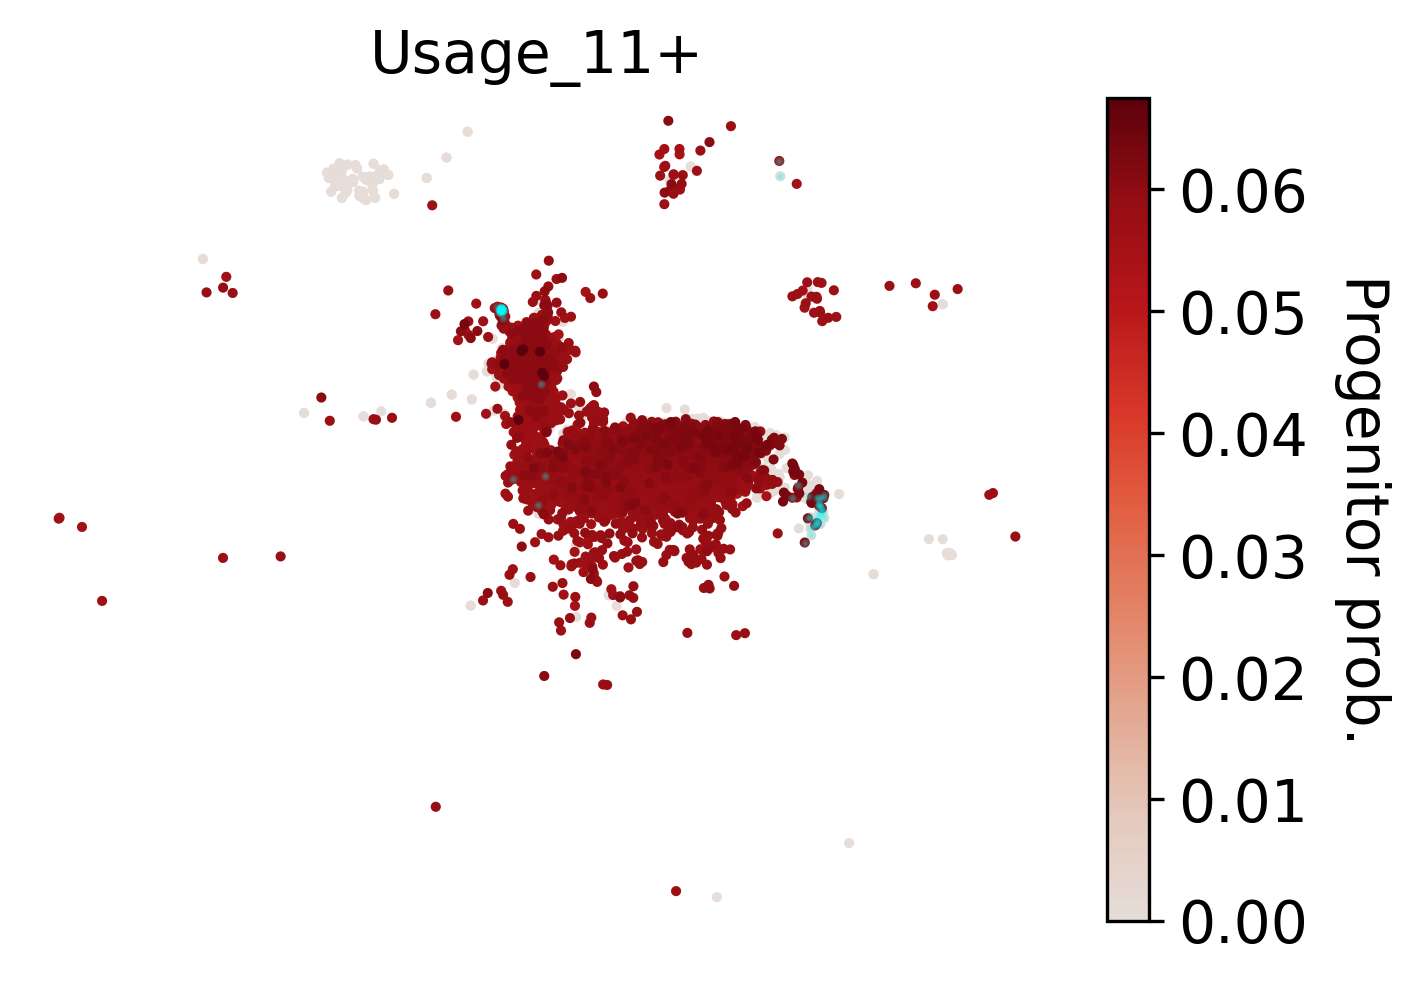

In [31]:
cs.tl.fate_map(
    adata,
    selected_fates=["Usage_11+"],
    source="transition_map",
    map_backward=True,
)
cs.pl.fate_map(
    adata,
    selected_fates=["Usage_11+"],
    source="transition_map",
    plot_target_state=True,
    show_histogram=False,
)



Results saved at adata.obs['fate_map_transition_map_Other']


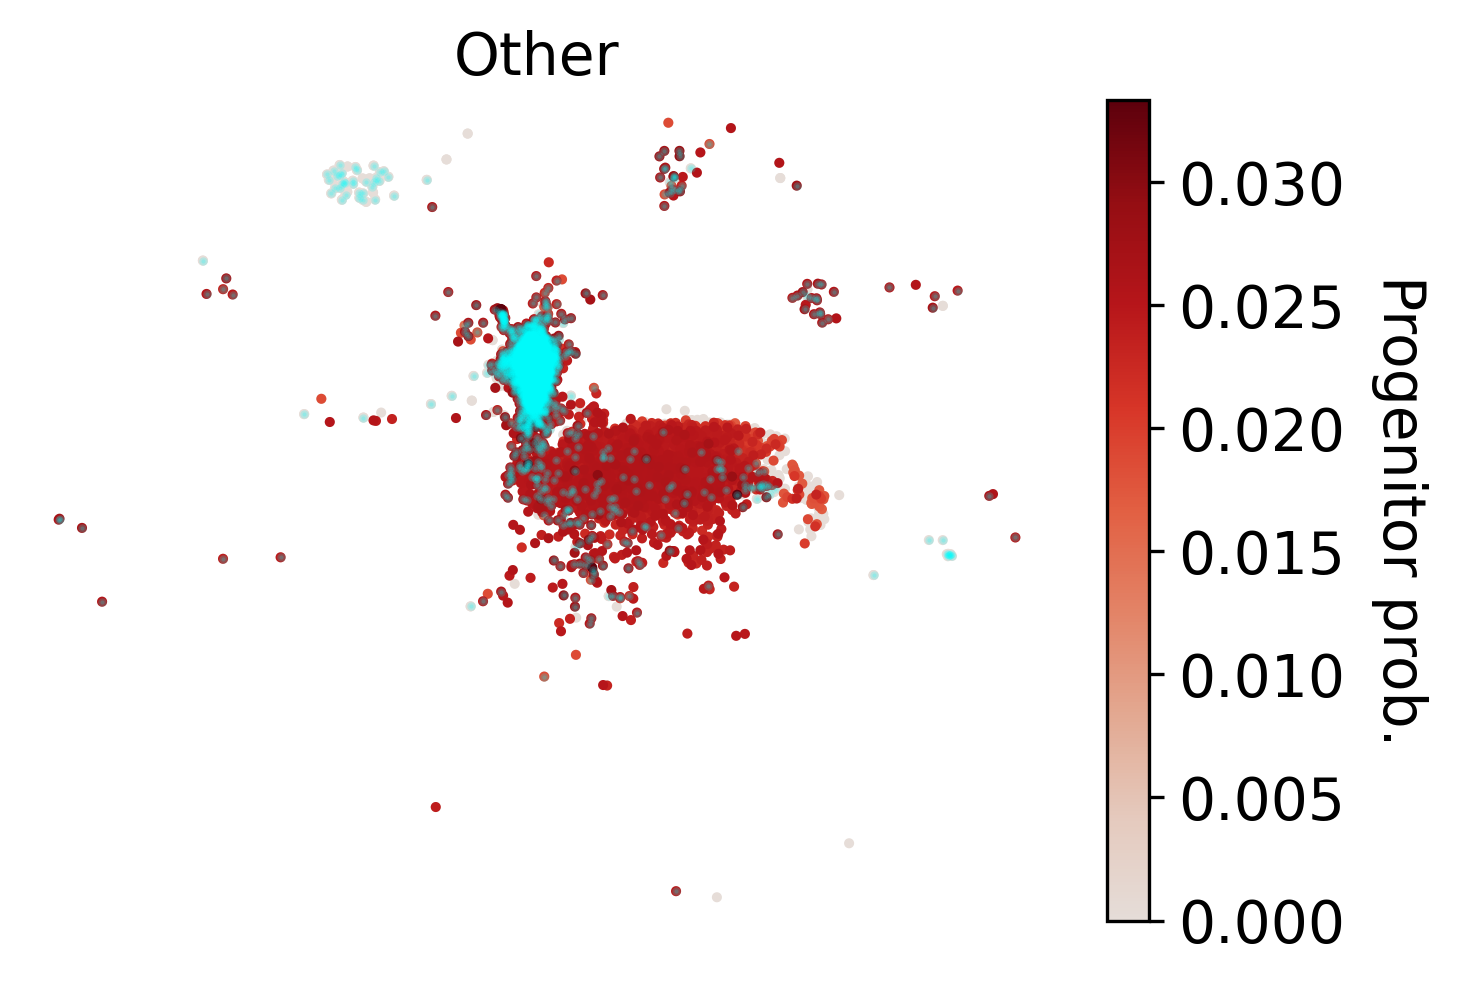

In [32]:
cs.tl.fate_map(
    adata,
    selected_fates=["Other"],
    source="transition_map",
    map_backward=True,
)
cs.pl.fate_map(
    adata,
    selected_fates=["Other"],
    source="transition_map",
    plot_target_state=True,
    show_histogram=False,
)



/tmp/ipykernel_1125406/3344638155.py:134: RuntimeWarning: All-NaN slice encountered
  vmin = min(np.nanmin(m.values) for m in panel_mats)
/tmp/ipykernel_1125406/3344638155.py:135: RuntimeWarning: All-NaN slice encountered
  vmax = max(np.nanmax(m.values) for m in panel_mats)


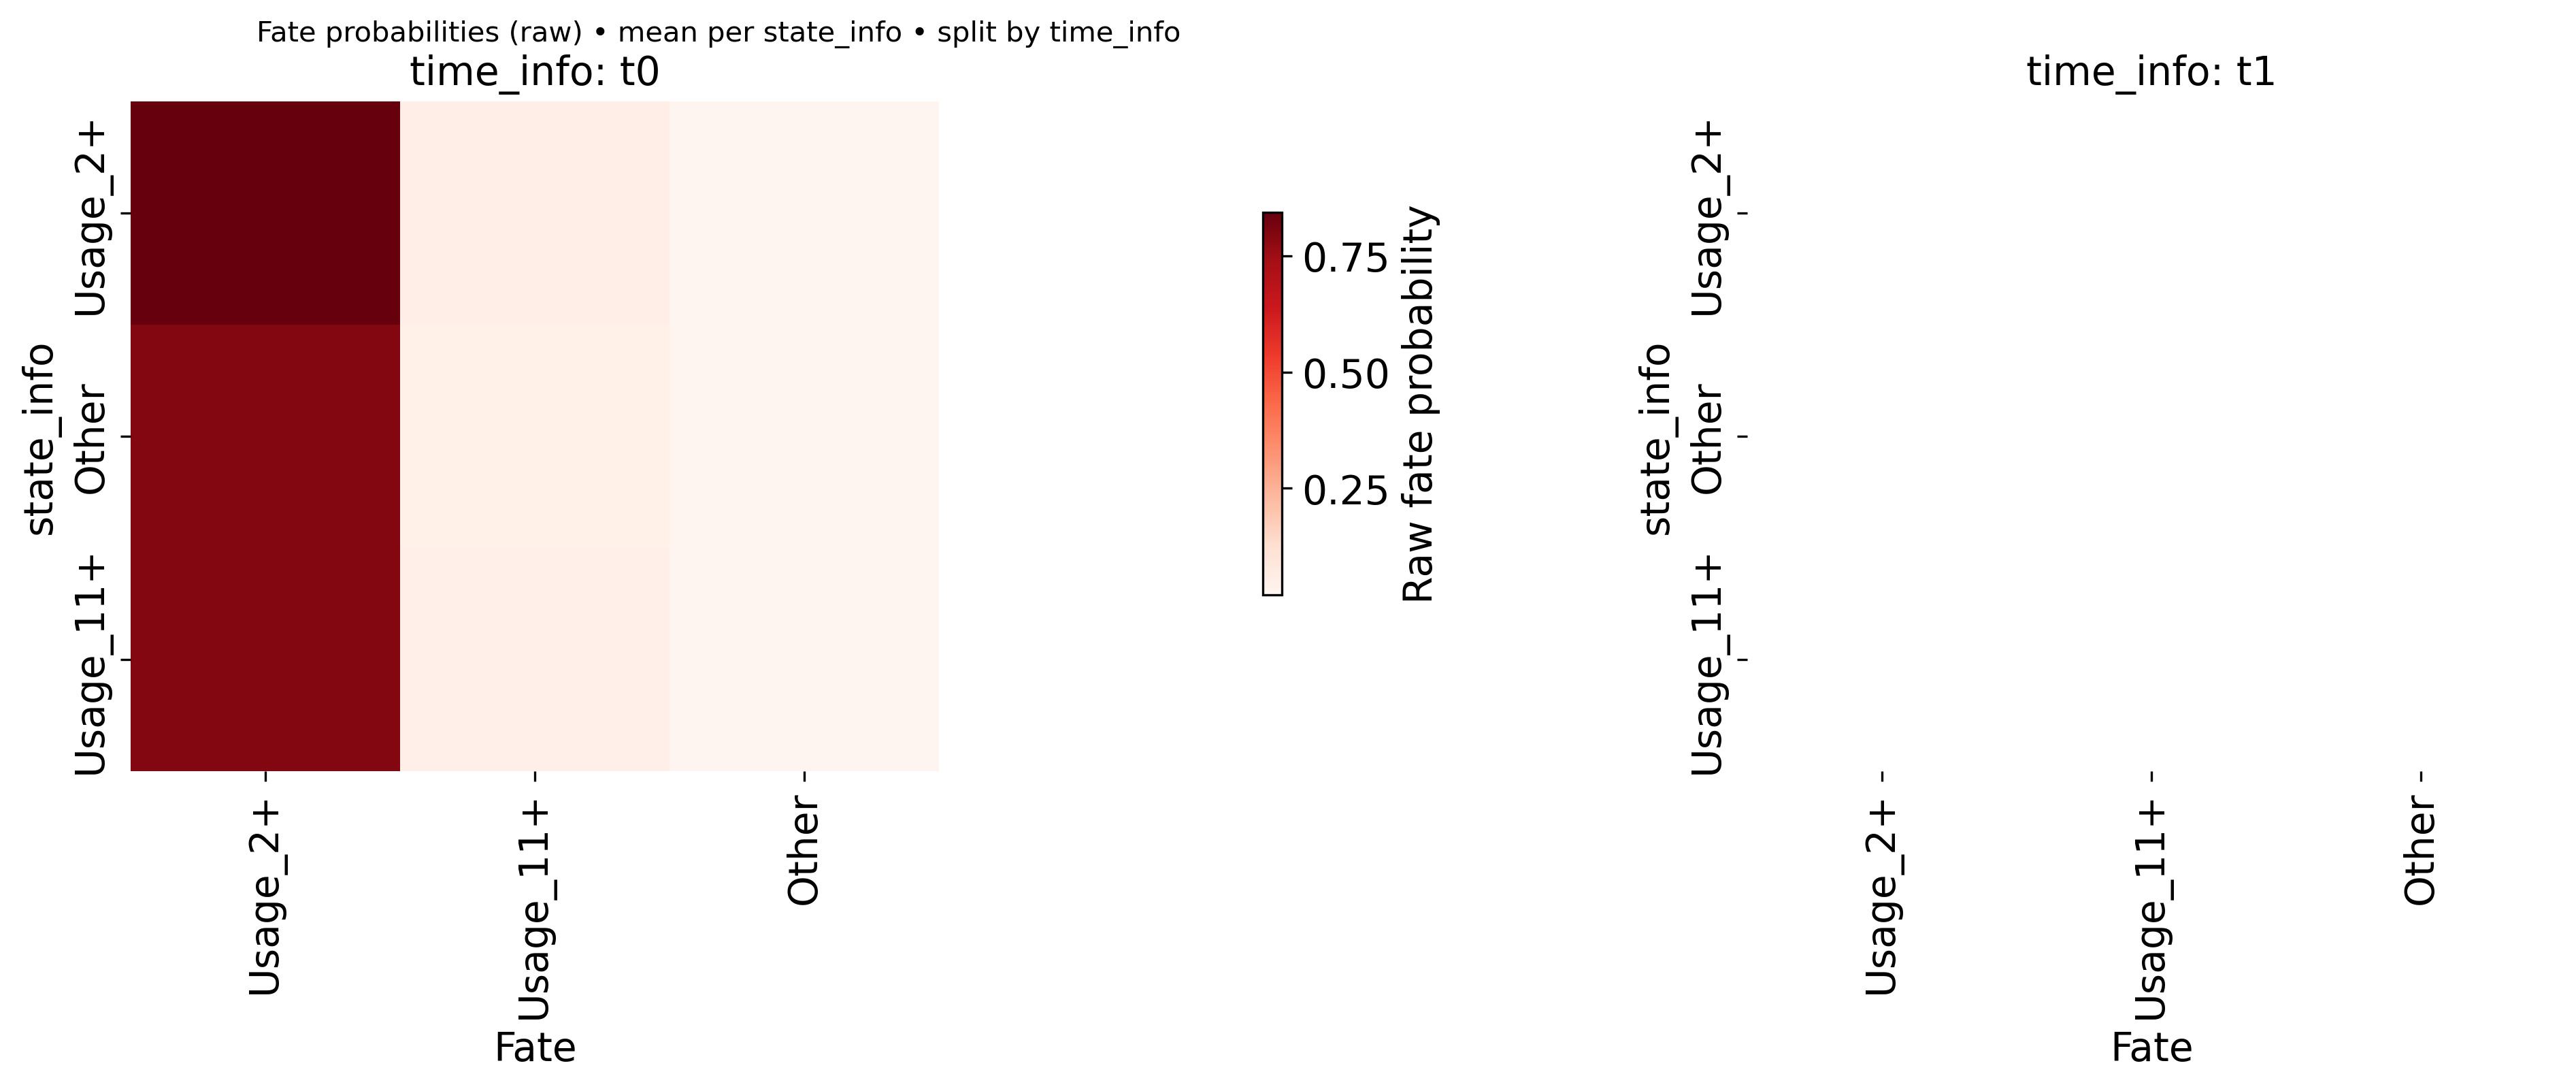

In [36]:
# --- Config you can tweak ---
cluster_key = "state_info"              # which annotation to aggregate by
prefix = "fate_map_transition_map_"             # columns in .obs with fate scores
time_candidates = ["time_info"]           # we'll auto-pick
zscore_mode = "raw"                             # NEW DEFAULT: "raw" | "global" | "per_time"
min_cells_per_cluster = 5                       # drop clusters with fewer cells than this in a time panel

# Choose which fates to show (after removing the prefix). Example: ["Endocardial","Epicardial"]
# Use None to keep all fates found.
fates_include = ["Usage_2+","Usage_11+","Other"]

# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

# --- 0) Pick a time key that exists ---
time_key = next((k for k in time_candidates if k in adata.obs.columns), None)
if time_key is None:
    raise KeyError(f"None of {time_candidates} found in adata.obs. "
                   f"Available columns: {list(adata.obs.columns)}")

if cluster_key not in adata.obs.columns:
    raise KeyError(f"'{cluster_key}' not found in adata.obs columns.")

# --- 1) Collect fate-probability columns from .obs ---
pp_cols = [c for c in adata.obs.columns if c.startswith(prefix)]
if len(pp_cols) == 0:
    raise ValueError(f"No columns in adata.obs start with '{prefix}'.")

pp_raw = adata.obs[pp_cols].apply(pd.to_numeric, errors="coerce").copy()
fate_names = [c.replace(prefix, "") for c in pp_cols]
pp_raw.columns = fate_names

# Optional: subset to user-specified fates
if fates_include is not None:
    missing = sorted(set(fates_include) - set(fate_names))
    if missing:
        raise ValueError(f"Requested fates not found: {missing}. Available: {sorted(fate_names)}")
    pp_raw = pp_raw[fates_include]

# Labels
clusters = adata.obs[cluster_key].astype(str)
times = adata.obs[time_key].astype(str)

# --- 2) Z-score setup (kept for compatibility, but "raw" is now default) ---
if zscore_mode not in ("raw", "global", "per_time"):
    raise ValueError("zscore_mode must be 'raw', 'global', or 'per_time'.")

def zscore_df(df):
    m = df.mean(axis=0)
    s = df.std(axis=0, ddof=0).replace(0, np.nan)
    return (df - m) / s

if zscore_mode == "global":
    col_means = pp_raw.mean(axis=0)
    col_stds  = pp_raw.std(axis=0, ddof=0).replace(0, np.nan)
    def apply_transform(df): return (df - col_means) / col_stds
elif zscore_mode == "per_time":
    def apply_transform(df): return zscore_df(df)
else:  # "raw"
    def apply_transform(df): return df

# --- 3) Build a reference ordering so panels align ---
# For ordering, use the same scale as plotting (i.e., after transform)
if zscore_mode == "per_time":
    parts = []
    for t in times.unique():
        mask_t = (times == t)
        parts.append(apply_transform(pp_raw.loc[mask_t]))
    pp_for_order = pd.concat(parts, axis=0)
else:
    pp_for_order = apply_transform(pp_raw)

heat_ref = pp_for_order.groupby(clusters).mean()
# Order rows by their maximum signal and columns by variance (most informative first)
row_order_ref = heat_ref.max(axis=1).sort_values(ascending=False).index
col_order_ref = heat_ref.var(axis=0).sort_values(ascending=False).index

# --- 4) Compute one heatmap per time ---
time_levels = sorted(times.unique(), key=lambda x: x)

panel_mats = []
panel_titles = []

for t in time_levels:
    mask_t = (times == t)
    if mask_t.sum() == 0:
        continue

    pp_t = pp_raw.loc[mask_t]
    clusters_t = clusters.loc[mask_t]

    # transform depending on mode (raw leaves as-is)
    pp_plot = apply_transform(pp_t)

    # drop clusters with too few cells
    valid_clusters = clusters_t.value_counts()
    keep_clusters = valid_clusters[valid_clusters >= min_cells_per_cluster].index
    if len(keep_clusters) == 0:
        continue

    # aggregate
    heat_t = pp_plot.groupby(clusters_t).mean()
    heat_t = heat_t.loc[heat_t.index.intersection(keep_clusters)]

    # align to reference ordering (drop missing)
    heat_t = heat_t.reindex(index=[i for i in row_order_ref if i in heat_t.index],
                            columns=[c for c in col_order_ref if c in heat_t.columns])

    panel_mats.append(heat_t)
    panel_titles.append(str(t))

if len(panel_mats) == 0:
    raise RuntimeError("No panels to plot (after filtering / alignment). Try lowering min_cells_per_cluster.")

# --- 5) Plot grid of heatmaps (max 2 per row) ---
n_panels = len(panel_mats)
ncols = min(2, n_panels)
nrows = int(ceil(n_panels / ncols))

# Figure size scales with matrix size and number of panels
n_fates = len(col_order_ref)
n_rows_max = max(m.shape[0] for m in panel_mats)

fig_w = 3 * ncols
fig_h = max(4, 0.32 * n_rows_max) * nrows

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h), squeeze=False)

# Shared color scale
vmin = min(np.nanmin(m.values) for m in panel_mats)
vmax = max(np.nanmax(m.values) for m in panel_mats)

# Plot each panel
idx = 0
for r in range(nrows):
    for c in range(ncols):
        ax = axes[r, c]
        if idx < n_panels:
            mat = panel_mats[idx]
            sns.heatmap(
                mat, ax=ax,
                cmap="vlag" if zscore_mode != "raw" else "Reds",  # nicer for raw [0..1]; keep vlag for z
                center=0 if zscore_mode != "raw" else None,
                vmin=vmin, vmax=vmax,
                cbar=False
            )
            ax.set_title(f"{time_key}: {panel_titles[idx]}")
            ax.set_xlabel("Fate")
            ax.set_ylabel(cluster_key)
            ax.tick_params(axis="x", labelrotation=90)
        else:
            ax.axis("off")
        idx += 1

# Shared colorbar
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = "vlag" if zscore_mode != "raw" else "Reds"
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.01)
cbar.set_label("Raw fate probability" if zscore_mode == "raw" else "Z-scored fate probability")

fig.suptitle(
    f"Fate probabilities ({zscore_mode}) • mean per {cluster_key} • split by {time_key}",
    y=1, fontsize=10
)

# Roomier margins & spacing
fig.subplots_adjust(
    wspace=1,
    hspace=1.0,
    left=0.02,
    right=2,
    top=0.9,
    bottom=0.08
)

plt.show()


/tmp/ipykernel_1125406/3219916036.py:134: RuntimeWarning: All-NaN slice encountered
  vmin = min(np.nanmin(m.values) for m in panel_mats)
/tmp/ipykernel_1125406/3219916036.py:135: RuntimeWarning: All-NaN slice encountered
  vmax = max(np.nanmax(m.values) for m in panel_mats)


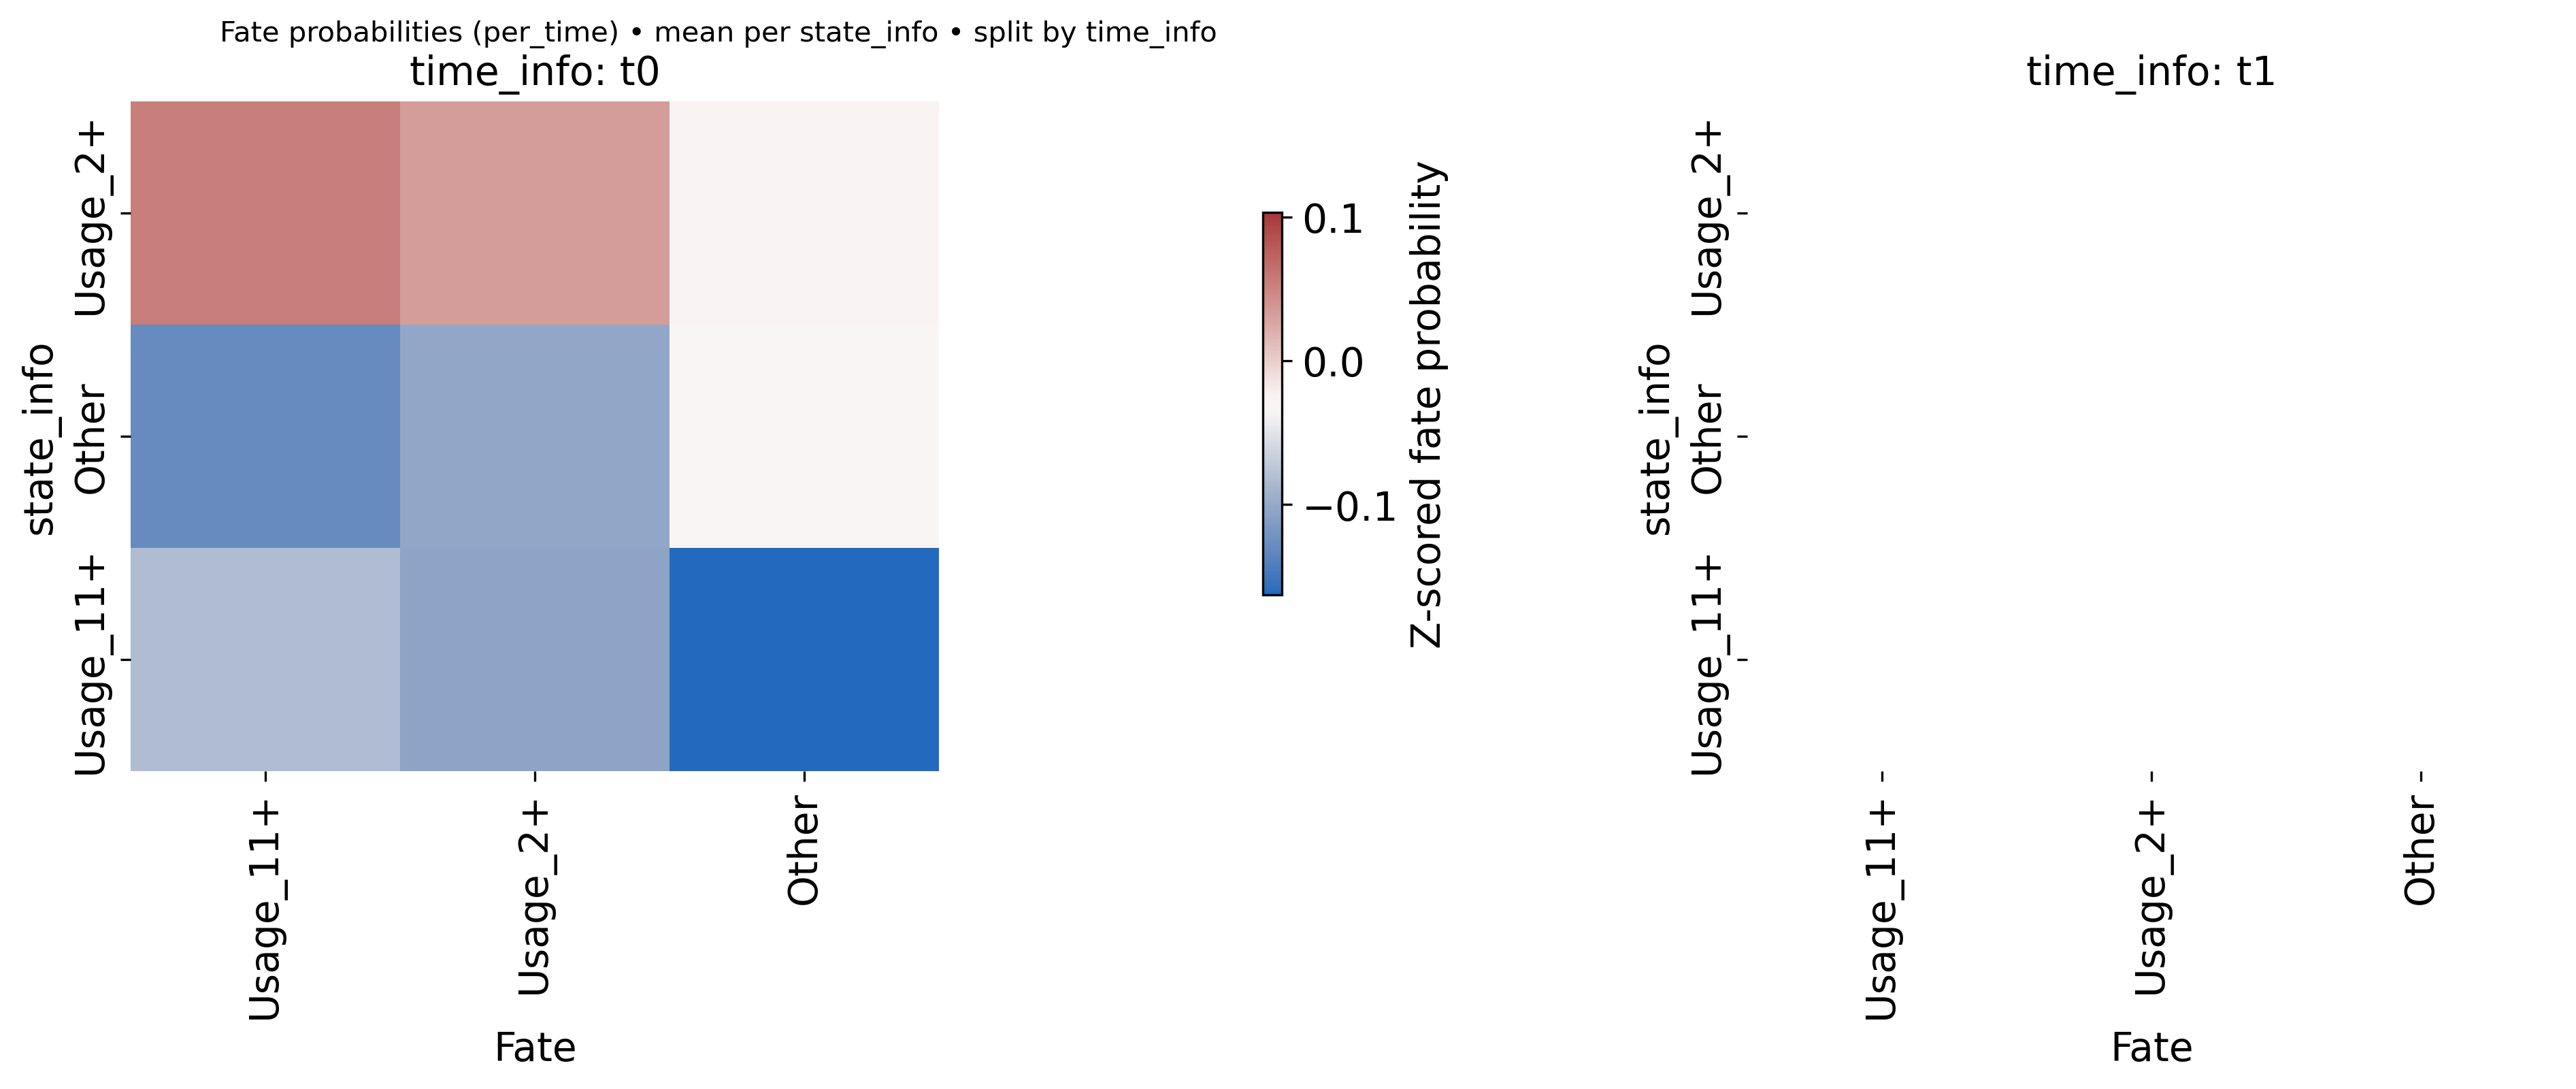

In [35]:
# --- Config you can tweak ---
cluster_key = "state_info"              # which annotation to aggregate by
prefix = "fate_map_transition_map_"             # columns in .obs with fate scores
time_candidates = ["time_info"]           # we'll auto-pick
zscore_mode = "per_time"                             # NEW DEFAULT: "raw" | "global" | "per_time"
min_cells_per_cluster = 5                       # drop clusters with fewer cells than this in a time panel

# Choose which fates to show (after removing the prefix). Example: ["Endocardial","Epicardial"]
# Use None to keep all fates found.
fates_include = ["Usage_2+","Usage_11+","Other"]

# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

# --- 0) Pick a time key that exists ---
time_key = next((k for k in time_candidates if k in adata.obs.columns), None)
if time_key is None:
    raise KeyError(f"None of {time_candidates} found in adata.obs. "
                   f"Available columns: {list(adata.obs.columns)}")

if cluster_key not in adata.obs.columns:
    raise KeyError(f"'{cluster_key}' not found in adata.obs columns.")

# --- 1) Collect fate-probability columns from .obs ---
pp_cols = [c for c in adata.obs.columns if c.startswith(prefix)]
if len(pp_cols) == 0:
    raise ValueError(f"No columns in adata.obs start with '{prefix}'.")

pp_raw = adata.obs[pp_cols].apply(pd.to_numeric, errors="coerce").copy()
fate_names = [c.replace(prefix, "") for c in pp_cols]
pp_raw.columns = fate_names

# Optional: subset to user-specified fates
if fates_include is not None:
    missing = sorted(set(fates_include) - set(fate_names))
    if missing:
        raise ValueError(f"Requested fates not found: {missing}. Available: {sorted(fate_names)}")
    pp_raw = pp_raw[fates_include]

# Labels
clusters = adata.obs[cluster_key].astype(str)
times = adata.obs[time_key].astype(str)

# --- 2) Z-score setup (kept for compatibility, but "raw" is now default) ---
if zscore_mode not in ("raw", "global", "per_time"):
    raise ValueError("zscore_mode must be 'raw', 'global', or 'per_time'.")

def zscore_df(df):
    m = df.mean(axis=0)
    s = df.std(axis=0, ddof=0).replace(0, np.nan)
    return (df - m) / s

if zscore_mode == "global":
    col_means = pp_raw.mean(axis=0)
    col_stds  = pp_raw.std(axis=0, ddof=0).replace(0, np.nan)
    def apply_transform(df): return (df - col_means) / col_stds
elif zscore_mode == "per_time":
    def apply_transform(df): return zscore_df(df)
else:  # "raw"
    def apply_transform(df): return df

# --- 3) Build a reference ordering so panels align ---
# For ordering, use the same scale as plotting (i.e., after transform)
if zscore_mode == "per_time":
    parts = []
    for t in times.unique():
        mask_t = (times == t)
        parts.append(apply_transform(pp_raw.loc[mask_t]))
    pp_for_order = pd.concat(parts, axis=0)
else:
    pp_for_order = apply_transform(pp_raw)

heat_ref = pp_for_order.groupby(clusters).mean()
# Order rows by their maximum signal and columns by variance (most informative first)
row_order_ref = heat_ref.max(axis=1).sort_values(ascending=False).index
col_order_ref = heat_ref.var(axis=0).sort_values(ascending=False).index

# --- 4) Compute one heatmap per time ---
time_levels = sorted(times.unique(), key=lambda x: x)

panel_mats = []
panel_titles = []

for t in time_levels:
    mask_t = (times == t)
    if mask_t.sum() == 0:
        continue

    pp_t = pp_raw.loc[mask_t]
    clusters_t = clusters.loc[mask_t]

    # transform depending on mode (raw leaves as-is)
    pp_plot = apply_transform(pp_t)

    # drop clusters with too few cells
    valid_clusters = clusters_t.value_counts()
    keep_clusters = valid_clusters[valid_clusters >= min_cells_per_cluster].index
    if len(keep_clusters) == 0:
        continue

    # aggregate
    heat_t = pp_plot.groupby(clusters_t).mean()
    heat_t = heat_t.loc[heat_t.index.intersection(keep_clusters)]

    # align to reference ordering (drop missing)
    heat_t = heat_t.reindex(index=[i for i in row_order_ref if i in heat_t.index],
                            columns=[c for c in col_order_ref if c in heat_t.columns])

    panel_mats.append(heat_t)
    panel_titles.append(str(t))

if len(panel_mats) == 0:
    raise RuntimeError("No panels to plot (after filtering / alignment). Try lowering min_cells_per_cluster.")

# --- 5) Plot grid of heatmaps (max 2 per row) ---
n_panels = len(panel_mats)
ncols = min(2, n_panels)
nrows = int(ceil(n_panels / ncols))

# Figure size scales with matrix size and number of panels
n_fates = len(col_order_ref)
n_rows_max = max(m.shape[0] for m in panel_mats)

fig_w = 3 * ncols
fig_h = max(4, 0.32 * n_rows_max) * nrows

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h), squeeze=False)

# Shared color scale
vmin = min(np.nanmin(m.values) for m in panel_mats)
vmax = max(np.nanmax(m.values) for m in panel_mats)

# Plot each panel
idx = 0
for r in range(nrows):
    for c in range(ncols):
        ax = axes[r, c]
        if idx < n_panels:
            mat = panel_mats[idx]
            sns.heatmap(
                mat, ax=ax,
                cmap="vlag" if zscore_mode != "raw" else "Reds",  # nicer for raw [0..1]; keep vlag for z
                center=0 if zscore_mode != "raw" else None,
                vmin=vmin, vmax=vmax,
                cbar=False
            )
            ax.set_title(f"{time_key}: {panel_titles[idx]}")
            ax.set_xlabel("Fate")
            ax.set_ylabel(cluster_key)
            ax.tick_params(axis="x", labelrotation=90)
        else:
            ax.axis("off")
        idx += 1

# Shared colorbar
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = "vlag" if zscore_mode != "raw" else "Reds"
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.01)
cbar.set_label("Raw fate probability" if zscore_mode == "raw" else "Z-scored fate probability")

fig.suptitle(
    f"Fate probabilities ({zscore_mode}) • mean per {cluster_key} • split by {time_key}",
    y=1, fontsize=10
)

# Roomier margins & spacing
fig.subplots_adjust(
    wspace=1,
    hspace=1.0,
    left=0.02,
    right=2,
    top=0.9,
    bottom=0.08
)

plt.show()
